# 01 - Fine-tuning EfficientNet-B0 con MURA

Este notebook entrena un modelo real para sustituir el simulador probabilistico inicial. Se usa **EfficientNet-B0 preentrenada en ImageNet** mediante `torchvision` y se ajusta con MURA-v1.1.

La idea no es validar clinicamente BoneView, sino tener un modelo real de apoyo a la deteccion de anormalidad musculoesqueletica para alimentar el sistema de vigilancia poscomercializacion.

En esta version el entrenamiento deja de ser una prueba rapida: se usa todo el `train` descargado de MURA y se hace un fine-tuning en dos fases. El `valid` oficial de MURA se mantiene separado hasta el final para mantener la independencia de la evaluación final.

Salidas principales del notebook:

- `code/modelos/efficientnet_b0_mura_final.pt`
- `code/outputs/tablas/registro_inferencias_modelo.csv`


## A. Preparación del entorno

En esta sección se importan las librerías necesarias, se definen las rutas del proyecto, se crea la estructura mínima de carpetas de salida y se selecciona el dispositivo de entrenamiento. También se fija una semilla básica para mejorar la repetibilidad de los experimentos.

Esto es importante para el TFG porque deja trazabilidad sobre **qué entorno se ha usado**, **dónde se guardan las salidas** y **cómo se ha garantizado que el entrenamiento sea reproducible dentro de lo razonable**. Además, aquí se deja explícito que el modelo parte de pesos oficiales de ImageNet (`torchvision`) y que el entrenamiento posterior con MURA es propio.

**Relación con el objetivo del TFG.** Este notebook representa la fase *offline* de desarrollo y validación del modelo que alimentará la app de vigilancia poscomercialización. Por tanto, conviene dejar bien documentadas desde el principio las dependencias, rutas y decisiones de ejecución.


In [ ]:
# Importamos librerías

import os  # Permite interactuar con el sistema de archivos, como crear carpetas o construir rutas.
from pathlib import Path  # Permite trabajar con rutas de archivos

import time
import hashlib
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageDraw

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    cohen_kappa_score, roc_curve, precision_recall_curve, average_precision_score
)

# Pesos oficiales de torchvision entrenados sobre ImageNet. A partir de aqui se hace fine-tuning real con MURA.
PESOS_EFFICIENTNET = EfficientNet_B0_Weights.DEFAULT  # Usamos la versión oficial preentrenada que trae torchvision

# Rutas del proyecto. Este notebook debe ejecutarse desde la raiz del repo de codigo.
DIR_REPO = Path.cwd().resolve()

if not (DIR_REPO / "app.py").exists():
    raise RuntimeError("Ejecuta este notebook desde la carpeta raiz del repositorio de codigo.")

RAIZ = str(DIR_REPO)
DIR_DATOS = str(DIR_REPO / "data")
DIR_MURA = str(DIR_REPO / "data" / "MURA-v1.1")
DIR_TABLAS = str(DIR_REPO / "outputs" / "tablas")
DIR_FIGURAS = str(DIR_REPO / "outputs" / "figuras")
DIR_IMAGENES_ANALIZADAS = str(DIR_REPO / "outputs" / "imagenes_analizadas")
DIR_MODELOS = str(DIR_REPO / "modelos")

os.makedirs(DIR_DATOS, exist_ok=True)
for carpeta in [DIR_TABLAS, DIR_FIGURAS, DIR_IMAGENES_ANALIZADAS, DIR_MODELOS]:
    os.makedirs(carpeta, exist_ok=True)

# La semilla sirve para que el muestreo y parte del entrenamiento sean repetibles.
SEMILLA = 42
torch.manual_seed(SEMILLA)

# En mi Mac uso MPS (Metal Performance Shaders) para aprovechar al máximo la GPU si esta disponible; si no, el notebook funciona en CPU.
DISPOSITIVO = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print("RAIZ:", RAIZ)
print("MURA:", DIR_MURA)


RAIZ: .
MURA: data/MURA-v1.1


## B. Configuración del experimento

En esta sección se fijan los hiperparámetros principales del entrenamiento: tamaño de imagen, *batch size*, número máximo de épocas, paciencia de *early stopping*, tasas de aprendizaje y métrica usada para conservar el mejor estado del modelo en memoria. También se deja por escrito cómo se reparten las particiones de MURA para evitar fuga de datos: el `train` oficial se utilizará para **entrenamiento + validación interna**, mientras que el `valid` oficial quedará reservado para la **evaluación final honesta** y para generar los CSV que consume la aplicación de vigilancia.

### 1) Mejoras aplicadas 

Estas mejoras salen de comparar nuestro notebook con el notebook de referencia del repositorio, pero manteniendo limpia la evaluación final:

1. **Usar todo el `train` de MURA**. En la versión final no se limita el número de imágenes: se aprovecha todo el `train` descargado para entrenar y el `valid` oficial queda reservado para la evaluación final.
2. **Aumentos de datos algo más completos**. Se añade `RandomHorizontalFlip`, que es razonable en radiografías MSK porque no cambia la etiqueta normal/anormal y ayuda a generalizar.
3. **Fine-tuning en dos fases**. Primero se entrenan cabezales y últimos bloques; después se descongela toda EfficientNet-B0 con una tasa de aprendizaje baja. Así se adapta el modelo a radiografías sin destruir de golpe los pesos preentrenados.
4. **Selección por validación interna**. El mejor estado del modelo se elige usando una métrica de la validación interna (`valid_auc`), nunca usando el `valid` oficial de MURA. Esto evita optimizar contra el conjunto final sin guardar estados del modelo en disco.
5. **Umbral optimizado en validación interna**. El umbral de decisión normal/anormal se calcula con la validación interna maximizando F1. Después se aplica una sola vez sobre el `valid` oficial.

Estas decisiones permiten mejorar el entrenamiento sin tocar el `valid` oficial para elegir hiperparámetros, por lo que la evaluación final sigue siendo limpia.

**Relación con el objetivo del TFG.** Esta configuración marca cómo se obtiene el modelo sustituto de BoneView/Gleamer que se usará después en la vigilancia poscomercialización. No busca una optimización extrema, sino un equilibrio entre rendimiento, claridad y trazabilidad académica.


### 2) Justificación de hiperparámetros del entrenamiento

Esta celda define la configuración principal del fine-tuning de EfficientNet-B0 sobre MURA. Los valores no se han elegido todos por la misma razón: algunos vienen condicionados por la arquitectura oficial de EfficientNet-B0 en `torchvision`, otros se han tomado como referencia del notebook externo analizado, otros son prácticas habituales de fine-tuning, y otros son decisiones propias del proyecto. Durante el entrenamiento no se guardan guardados intermedios: el mejor estado se conserva en memoria y solo se guarda una vez el modelo final al terminar.

No se ha realizado una búsqueda exhaustiva de hiperparámetros, porque el objetivo principal del TFG no es batir el estado del arte en MURA, sino entrenar un modelo real y trazable que alimente el prototipo de vigilancia poscomercialización.

| Parámetro | Valor | Para qué sirve | Justificación |
|---|---:|---|---|
| `TAM_IMAGEN` | `224` | Tamaño final de entrada de las imágenes. | EfficientNet-B0 preentrenada en `torchvision` usa transformaciones con recorte central de `224x224`. El notebook de referencia también redimensiona las imágenes a `224x224`. Por tanto, este valor viene tanto de la arquitectura/preentrenamiento como del repositorio usado como referencia. |
| `TAM_LOTE` | `32` | Número de imágenes procesadas antes de actualizar pesos. | Coincide con el notebook de referencia. Es un valor estándar: suficientemente grande para estabilizar el gradiente, pero asumible en memoria. |
| `EPOCAS_MAX` | `20` | Máximo de épocas por fase de entrenamiento. | Coincide con el notebook de referencia. No significa que siempre se entrenen 20 épocas, porque el early stopping puede parar antes. |
| `PACIENCIA_EARLY_STOP` | `5` | Número de épocas sin mejora antes de detener el entrenamiento. | Coincide con el notebook de referencia. Sirve para evitar sobreajuste y no seguir entrenando cuando la validación ya no mejora. |
| `MEJORA_MINIMA` | `1e-3` | Mejora mínima necesaria para considerar que el modelo ha mejorado. | Decisión de diseño del prototipo. Evita guardar estados del modelo por cambios muy pequeños que pueden ser ruido estadístico. |
| `PACIENCIA_LR` | `2` | Épocas sin mejora antes de reducir el learning rate. | Coincide con el scheduler del notebook de referencia. Si la validación se estanca, se baja la tasa de aprendizaje. |
| `FACTOR_LR` | `0.5` | Factor por el que se reduce el learning rate. | Coincide con el notebook de referencia. Reducir a la mitad es una práctica habitual. |
| `TASA_APRENDIZAJE` | `1e-4` | Learning rate principal para las capas nuevas/cabezales. | Coincide con el notebook de referencia y es habitual en fine-tuning con modelos preentrenados. |
| `TASA_APRENDIZAJE_BACKBONE` | `1e-5` | Learning rate para el extractor de características de EfficientNet. | Decisión de diseño del prototipo. Es menor que `1e-4` para modificar con más cuidado las capas preentrenadas y no destruir representaciones aprendidas en ImageNet. |
| `REGULARIZACION_PESO` | `1e-4` | Penalización L2/weight decay para reducir sobreajuste. | Coincide con el notebook de referencia. Es un valor estándar en entrenamiento con Adam/AdamW. |
| `PESO_PERDIDA_ANATOMIA` | `0.50` | Peso de la pérdida auxiliar de parte anatómica. | Decisión de diseño del prototipo. La tarea principal es normal/anormal; la anatomía ayuda como tarea auxiliar, pero no debe dominar el entrenamiento. |
| `UMBRAL_DECISION` | `0.50` | Umbral inicial para convertir probabilidad en etiqueta binaria. | Es el umbral estándar en clasificación binaria. Después se optimiza con validación interna, por lo que no se ajusta usando el conjunto valid oficial. |
| `OBJETIVO_UMBRAL` | `'f1'` | Métrica usada para elegir el mejor umbral. | Decisión de diseño del prototipo. F1 equilibra precisión y recall, útil cuando interesan tanto los falsos positivos como los falsos negativos. |
| `METRICA_SELECCION_MODELO` | `'valid_auc'` | Métrica usada para seleccionar el mejor estado del modelo durante el entrenamiento. | DDecisión de diseño del prototipo. AUC mide la capacidad de separar normal/anormal sin depender de un umbral fijo. |
| `FRACCION_VALIDACION_TRAIN` | `0.20` | Porcentaje de train reservado para validación interna. | Decisión de diseño del prototipo. Permite ajustar umbral, early stopping y estado del modelo sin tocar el valid oficial de MURA. |
| `VERSION_MODELO` | `'EfficientNet-B0 fine-tuned MURA v1.2'` | Nombre trazable de la versión del modelo. | Decisión de gobernanza. Sirve para auditoría, informes y trazabilidad. |
| `RUTA_MODELO_FINAL` | `efficientnet_b0_mura_final.pt` | Ruta donde se guarda una única copia final del modelo entrenado. | Decisión práctica. No hay guardados por época; solo se conserva el artefacto final para poder reutilizarlo después. |
| `PARTES_ANATOMICAS` | lista de 7 partes | Clases anatómicas presentes en MURA. | Sale directamente de la estructura del dataset MURA: elbow, finger, forearm, hand, humerus, shoulder y wrist. |
| `PARTE_A_INDICE` | diccionario | Convierte cada parte anatómica en un índice numérico. | Necesario para entrenar la cabeza auxiliar de clasificación anatómica. |

### 3) Relación con EfficientNet-B0 oficial

La documentación de `torchvision` indica que `EfficientNet_B0_Weights.DEFAULT` equivale a pesos preentrenados en ImageNet-1K. Las transformaciones oficiales redimensionan la imagen, hacen un recorte de `224x224` y normalizan con las medias y desviaciones típicas de ImageNet.

Por eso usamos `TAM_IMAGEN = 224`: no es un número arbitrario, sino el tamaño de entrada asociado al preentrenamiento de EfficientNet-B0. Mantener este tamaño hace que el fine-tuning sea coherente con el modelo base.

### 4) Relación con el notebook de referencia

Del notebook externo se toman como referencia varios valores:

- imagen `224x224`,
- `batch_size = 32`,
- `learning rate = 1e-4`,
- `weight_decay = 1e-4`,
- `epochs = 20`,
- `early stopping` con paciencia `5`,
- scheduler con paciencia `2` y factor `0.5`,
- arquitectura multitarea con predicción principal normal/anormal y apoyo de parte anatómica.

En este TFG no se copia el experimento completo, sino que se adapta esa configuración a nuestro flujo: entrenamiento propio con MURA, generación de CSV para la app y trazabilidad para vigilancia poscomercialización.

### 5) Decisiones propias del proyecto

Algunos valores se han definido específicamente para este TFG:

- `TASA_APRENDIZAJE_BACKBONE = 1e-5`, para ajustar el backbone más suavemente.
- `MEJORA_MINIMA = 1e-3`, para evitar guardar mejoras irrelevantes.
- `PESO_PERDIDA_ANATOMIA = 0.50`, porque la anatomía es una tarea auxiliar.
- `METRICA_SELECCION_MODELO = 'valid_auc'`, porque interesa conservar en memoria el estado con buena separación probabilística.
- `FRACCION_VALIDACION_TRAIN = 0.20`, para disponer de validación interna sin contaminar el conjunto valid oficial.
- `VERSION_MODELO`, por trazabilidad y auditoría.
- `RUTA_MODELO_FINAL`, para guardar una sola copia final del modelo entrenado, sin generar guardados intermedios.

`num_workers=0` aparece directamente en los `DataLoader`, pero no se considera un hiperparámetro del modelo: solo evita problemas de multiprocesamiento en Jupyter/macOS. Del mismo modo, la versión final del notebook usa todo MURA train y todo MURA valid, sin límites artificiales de muestras.


In [44]:
# Hiperparametros principales del entrenamiento.
TAM_IMAGEN = 224
TAM_LOTE = 32
EPOCAS_MAX = 20

TASA_APRENDIZAJE = 1e-4
TASA_APRENDIZAJE_BACKBONE = 1e-5
REGULARIZACION_PESO = 1e-4

PACIENCIA_EARLY_STOP = 5
MEJORA_MINIMA = 1e-3
PACIENCIA_LR = 2
FACTOR_LR = 0.5

# La tarea de anatomia ayuda al modelo, pero la tarea principal es normal/anormal.
PESO_PERDIDA_ANATOMIA = 0.50

# Se empieza con 0.50, pero luego se optimiza usando solo la validacion interna.
UMBRAL_DECISION = 0.50
OBJETIVO_UMBRAL = 'f1'
METRICA_SELECCION_MODELO = 'valid_auc'
FRACCION_VALIDACION_TRAIN = 0.20

# Configuracion de trazabilidad del proyecto.
VERSION_MODELO = 'EfficientNet-B0 fine-tuned MURA v1.2'
RUTA_MODELO_FINAL = os.path.join(DIR_MODELOS, 'efficientnet_b0_mura_final.pt')

# Partes anatomicas oficiales que aparecen en MURA.
PARTES_ANATOMICAS = ['ELBOW', 'FINGER', 'FOREARM', 'HAND', 'HUMERUS', 'SHOULDER', 'WRIST']
PARTE_A_INDICE = {bp: i for i, bp in enumerate(PARTES_ANATOMICAS)}

print('Epocas maximas por fase:', EPOCAS_MAX)
print('Early stopping:', PACIENCIA_EARLY_STOP, 'epocas sin mejora')
print('Metrica seleccion modelo:', METRICA_SELECCION_MODELO)
print('Modelo final:', RUTA_MODELO_FINAL)

Epocas maximas por fase: 20
Early stopping: 5 epocas sin mejora
Metrica seleccion modelo: valid_auc
Modelo final: modelos/efficientnet_b0_mura_final.pt


## C. Lectura de MURA y construcción de los conjuntos de trabajo

En esta sección se carga el *manifest* (archivo con metadatos básicos) generado durante la descarga de MURA, se filtran únicamente las imágenes realmente descargadas y pertenecientes a las particiones `train` y `valid`, y se hace una limpieza pequeña pero importante: se descartan ficheros ocultos de macOS como `._image1.png`. Esos archivos no son radiografías, sino metadatos AppleDouble, y si entran en el `DataLoader` pueden provocar errores de apertura. También se comprueba que las rutas existen y que PIL puede abrir los ficheros, para detectar problemas al inicio y no a mitad del entrenamiento.

A partir de ahí se construyen los campos que luego son clave para el TFG: `local_path`, `body_part`, `body_part_idx`, `patient_id`, `study`, `study_id` y la etiqueta binaria `true_label`. Conviene recordar que **MURA no es un dataset específico de fracturas**, sino un dataset de **anormalidad musculoesquelética**. Por eso, en este trabajo el caso de uso se formula como clasificación **normal/anormal** sobre radiografías MSK, y no como diagnóstico clínico real de fractura.

Después se crean tres conjuntos:
- `datos_train`: imágenes usadas para ajustar pesos;
- `datos_val_train`: validación interna para *early stopping*, *scheduler*, estado del modelo y umbral;
- `datos_valid`: `valid` oficial de MURA, usado al final para evaluar y alimentar la app.

En esta versión se usa todo el `train` descargado de MURA. También se imprimen tablas y gráficas de distribución para comprobar si hay desbalance por etiqueta o por parte anatómica.


In [45]:
# Cargamos el manifest de MURA, que es un CSV con informacion sobre cada imagen.
manifest_mura = pd.read_csv(os.path.join(DIR_MURA, 'mura_manifest.csv'))  # Leemos csv y lo cargamos como un DataFrame de pandas.
display(manifest_mura.head())

# Nos quedamos solo con imagenes descargadas y con el split con valor de train o valid.
manifest_mura = manifest_mura[(manifest_mura['downloaded'] == True) & manifest_mura['split'].isin(['train', 'valid'])].copy()  # Hacemos una copia del DataFrame filtrado para evitar SettingWithCopyWarning.


# MURA descargado desde Redivis puede incluir ficheros ocultos de macOS tipo ._image1.png.
# Tienen extension .png, pero no son imagenes reales. Por eso los quitamos explicitamente.
def es_imagen_real_mura(ruta_relativa):
    nombre = os.path.basename(str(ruta_relativa))                                                         # Obtenemos el nombre del archivo a partir de la ruta relativa.
    return nombre.lower().endswith('.png') and not nombre.startswith('._') and not nombre.startswith('.') # Verificamos que termina en .png, no empieza con ._ ni con . Devuelve True o False

antes_limpieza = len(manifest_mura)
manifest_mura = manifest_mura[manifest_mura['relative_path'].apply(es_imagen_real_mura)].copy()           # Aplicamos la funcion a la columna 'relative_path' y nos quedamos solo con las filas donde devuelve True. Hacemos una copia del DataFrame resultante para evitar SettingWithCopyWarning.
print('Archivos descartados por no ser radiografias reales:', antes_limpieza - len(manifest_mura))


manifest_mura['local_path'] = manifest_mura['relative_path'].apply(lambda p: os.path.join(DIR_MURA, p))  # Creamos una nueva columna 'local_path' construyendo la ruta completa a cada imagen a partir de la ruta relativa y el directorio base de MURA.
manifest_mura = manifest_mura[manifest_mura['local_path'].apply(lambda p: os.path.exists(p))].copy()     # Nos quedamos solo con las filas donde el archivo existe en la ruta local. Hacemos una copia del DataFrame resultante para evitar SettingWithCopyWarning.


# Codificamos la parte anatomica para poder usarla en la cabeza auxiliar del modelo.
manifest_mura['body_part_idx'] = manifest_mura['body_part'].map(PARTE_A_INDICE)  # Creamos la columna 'body_part_idx' mapeando la columna 'body_part' a su indice correspondiente usando el diccionario PARTE_A_INDICE. Si alguna parte anatomica no esta en el diccionario, se asigna NaN.
manifest_mura = manifest_mura.dropna(subset=['body_part_idx']).copy()            # Nos quedamos solo con las filas donde 'body_part_idx' no es NaN, es decir, donde la parte anatomica esta en el diccionario. Hacemos una copia del DataFrame resultante para evitar SettingWithCopyWarning.
manifest_mura['body_part_idx'] = manifest_mura['body_part_idx'].astype(int)      # Convertimos la columna 'body_part_idx' a tipo entero, ya que es un indice que se usara como etiqueta en la cabeza auxiliar del modelo.

manifest_mura['study_id'] = 'XR_' + manifest_mura['body_part'] + '_' + manifest_mura['patient_id'] + '_' + manifest_mura['study']  # Creamos una columna 'study_id' concatenando 'XR_', la parte anatomica, el id del paciente y el id del estudio. Esto se usara para asegurarnos de que las imagenes del mismo estudio no se separen entre entrenamiento y validacion.

manifest_mura['body_part_fmt'] = 'XR_' + manifest_mura['body_part']              # Creamos una columna 'body_part_fmt'. Esto se usara para mostrar la parte anatomica en los resultados de forma mas clara.

# Train oficial de MURA: se divide en entrenamiento y validacion interna.
# Valid oficial de MURA: se deja para evaluacion final y para alimentar la app.
datos_train_original = manifest_mura[manifest_mura['split'] == 'train'].copy()
datos_valid = manifest_mura[manifest_mura['split'] == 'valid'].copy()

display(datos_train_original.head())
display(datos_valid.head())

# Del train oficial sacamos una validacion interna para early stopping, scheduler y ajuste del umbral.
datos_train, datos_val_train = train_test_split(
    datos_train_original,
    test_size=FRACCION_VALIDACION_TRAIN,
    random_state=SEMILLA,
    stratify=datos_train_original["true_label"]
)

datos_train = datos_train.reset_index(drop=True)
datos_val_train = datos_val_train.reset_index(drop=True)
datos_valid = datos_valid.reset_index(drop=True)

,file_id,file_name,size,added_at,md5_hash,split,body_part,patient_id,study,true_label,relative_path,expected_size,local_path,downloaded
0,gcvw-8sbb61dwy.gO5IC4xwWxAUUsDasTmUKg,valid/XR_SHOULDER/patient11735/study1_positive...,115318,2026-03-07 17:06:43.175000,ejnNN6MEckGAIZjC3zHl6w==,valid,SHOULDER,patient11735,study1_positive,1,valid/XR_SHOULDER/patient11735/study1_positive...,115318,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True
1,gcvw-8sbb61dwy.NH2qnAXQBhm55rM_goRkJg,valid/XR_SHOULDER/patient11738/study1_positive...,79333,2026-03-07 17:06:43.175000,XnHdh7XC3vvfw0sjDNR6Pw==,valid,SHOULDER,patient11738,study1_positive,1,valid/XR_SHOULDER/patient11738/study1_positive...,79333,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True
2,gcvw-8sbb61dwy.Kw2qYuOi4i4t3hzKFVGDbg,valid/XR_SHOULDER/patient11770/study1_negative...,56967,2026-03-07 17:06:43.175000,hGk5ZhYMC1+YqtZVwxJZGQ==,valid,SHOULDER,patient11770,study1_negative,0,valid/XR_SHOULDER/patient11770/study1_negative...,56967,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True
3,gcvw-8sbb61dwy.Ccz6BtJ7ZCW24r8dwPSsbQ,valid/XR_SHOULDER/patient11794/study1_negative...,43658,2026-03-07 17:06:43.175000,aJ1anfQwcg4QxhnkArXE9Q==,valid,SHOULDER,patient11794,study1_negative,0,valid/XR_SHOULDER/patient11794/study1_negative...,43658,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True
4,gcvw-8sbb61dwy.GPfYLrhLWxUKiCZkwQtkVQ,valid/XR_SHOULDER/patient11798/study1_negative...,54974,2026-03-07 17:06:43.175000,M+IKxg5R3BTb3ZErLmvIuw==,valid,SHOULDER,patient11798,study1_negative,0,valid/XR_SHOULDER/patient11798/study1_negative...,54974,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True


Archivos descartados por no ser radiografias reales: 4


,file_id,file_name,size,added_at,md5_hash,split,body_part,patient_id,study,true_label,relative_path,expected_size,local_path,downloaded,body_part_idx,study_id,body_part_fmt
2996,gcvw-8sbb61dwy.vmVxqx7BwuBu9W_1Ape4bQ,train/XR_WRIST/patient08820/study1_negative/im...,117434,2026-03-07 17:07:03.518000,ZOwWn6GgBb7kmnS6BI1APw==,train,WRIST,patient08820,study1_negative,0,train/XR_WRIST/patient08820/study1_negative/im...,117434,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True,6,XR_WRIST_patient08820_study1_negative,XR_WRIST
2997,gcvw-8sbb61dwy.9AB0tWLLtSE3D8USsbQcUw,train/XR_WRIST/patient08822/study1_negative/im...,37457,2026-03-07 17:07:03.518000,8HnQqY0z1Ig9Hx0p9LqBqA==,train,WRIST,patient08822,study1_negative,0,train/XR_WRIST/patient08822/study1_negative/im...,37457,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True,6,XR_WRIST_patient08822_study1_negative,XR_WRIST
2998,gcvw-8sbb61dwy.ilglJIqqOLP6IDEhyqakbg,train/XR_WRIST/patient08844/study1_negative/im...,66012,2026-03-07 17:07:03.518000,9lClPfcuQOIcMnQ9OcsoZw==,train,WRIST,patient08844,study1_negative,0,train/XR_WRIST/patient08844/study1_negative/im...,66012,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True,6,XR_WRIST_patient08844_study1_negative,XR_WRIST
2999,gcvw-8sbb61dwy.ak-4_K8d4B0Opy9tZACU7w,train/XR_WRIST/patient08849/study1_negative/im...,130512,2026-03-07 17:07:03.518000,k3eWj25hyzSQtfF5cXnlKg==,train,WRIST,patient08849,study1_negative,0,train/XR_WRIST/patient08849/study1_negative/im...,130512,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True,6,XR_WRIST_patient08849_study1_negative,XR_WRIST
3000,gcvw-8sbb61dwy.GzG33jz8Dwm8GO8f-VOyiw,train/XR_WRIST/patient08888/study1_negative/im...,151489,2026-03-07 17:07:03.518000,IlfDsgX3qboWyLGJrj0m2g==,train,WRIST,patient08888,study1_negative,0,train/XR_WRIST/patient08888/study1_negative/im...,151489,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True,6,XR_WRIST_patient08888_study1_negative,XR_WRIST


,file_id,file_name,size,added_at,md5_hash,split,body_part,patient_id,study,true_label,relative_path,expected_size,local_path,downloaded,body_part_idx,study_id,body_part_fmt
0,gcvw-8sbb61dwy.gO5IC4xwWxAUUsDasTmUKg,valid/XR_SHOULDER/patient11735/study1_positive...,115318,2026-03-07 17:06:43.175000,ejnNN6MEckGAIZjC3zHl6w==,valid,SHOULDER,patient11735,study1_positive,1,valid/XR_SHOULDER/patient11735/study1_positive...,115318,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True,5,XR_SHOULDER_patient11735_study1_positive,XR_SHOULDER
1,gcvw-8sbb61dwy.NH2qnAXQBhm55rM_goRkJg,valid/XR_SHOULDER/patient11738/study1_positive...,79333,2026-03-07 17:06:43.175000,XnHdh7XC3vvfw0sjDNR6Pw==,valid,SHOULDER,patient11738,study1_positive,1,valid/XR_SHOULDER/patient11738/study1_positive...,79333,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True,5,XR_SHOULDER_patient11738_study1_positive,XR_SHOULDER
2,gcvw-8sbb61dwy.Kw2qYuOi4i4t3hzKFVGDbg,valid/XR_SHOULDER/patient11770/study1_negative...,56967,2026-03-07 17:06:43.175000,hGk5ZhYMC1+YqtZVwxJZGQ==,valid,SHOULDER,patient11770,study1_negative,0,valid/XR_SHOULDER/patient11770/study1_negative...,56967,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True,5,XR_SHOULDER_patient11770_study1_negative,XR_SHOULDER
3,gcvw-8sbb61dwy.Ccz6BtJ7ZCW24r8dwPSsbQ,valid/XR_SHOULDER/patient11794/study1_negative...,43658,2026-03-07 17:06:43.175000,aJ1anfQwcg4QxhnkArXE9Q==,valid,SHOULDER,patient11794,study1_negative,0,valid/XR_SHOULDER/patient11794/study1_negative...,43658,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True,5,XR_SHOULDER_patient11794_study1_negative,XR_SHOULDER
4,gcvw-8sbb61dwy.GPfYLrhLWxUKiCZkwQtkVQ,valid/XR_SHOULDER/patient11798/study1_negative...,54974,2026-03-07 17:06:43.175000,M+IKxg5R3BTb3ZErLmvIuw==,valid,SHOULDER,patient11798,study1_negative,0,valid/XR_SHOULDER/patient11798/study1_negative...,54974,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True,5,XR_SHOULDER_patient11798_study1_negative,XR_SHOULDER


## D. Dataset, transformaciones y DataLoaders

Aquí se define la clase `DatasetMURA`, que es la responsable de abrir cada radiografía, convertirla al formato adecuado y devolver tanto la etiqueta principal de anormalidad como la etiqueta auxiliar de parte anatómica. También se definen las transformaciones de entrenamiento y validación y se crean los `DataLoader` que alimentarán el modelo.

Las imágenes se convierten a escala de grises y luego a RGB para que puedan pasar por una EfficientNet-B0 preentrenada en ImageNet. Además, se aplican normalización y aumentos suaves en entrenamiento para favorecer la generalización sin alterar la validación. En validación solo se usa un preprocesado determinista. Se incorpora `RandomHorizontalFlip` porque el repositorio de referencia lo utilizaba y, en este problema, no cambia la etiqueta de anormalidad.


In [46]:
# En train definimos una pequeña secuencia de pasos que se aplican a cada imagen de entrenamiento para que el modelo no memorice exactamente las imagenes. 
transformacion_train = transforms.Compose([
    transforms.Resize((TAM_IMAGEN, TAM_IMAGEN)),                                     # 224x224
    transforms.RandomHorizontalFlip(p=0.5),                                          # giramos con p 0.5 la imagen horizontalemnete
    transforms.RandomRotation(10),                                                   # rotamos la imagen aleatoriamente entre -10 y 10 grados
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.95, 1.05)),  # aplicamos una transformacion affine aleatoria sin rotacion, con traslacion de hasta 3% y escala entre 0.95 y 1.05
    transforms.ColorJitter(brightness=0.10, contrast=0.10),                          # modificamos ligeramente el brillo y contraste 
    transforms.ToTensor(),                                                           # convertimos ia¡magen a tensor de PyTorch ya que la red no trabaja con imágenes PIL, con valores entre 0 y 1 y con el canal de color primero (C, H, W)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),     # a partir de EfficientNet_B0_Weights.DEFAULT, que es el preprocesamiento recomendado para los pesos oficiales de EfficientNet-B0. Esto ayuda a que el modelo aproveche mejor lo aprendido en ImageNet durante el fine-tuning con MURA.
])

# En validacion no se meten aumentos, solo resize, tensor y normalizacion ya que queremos medir el rendimiento real del modelo sin introducir variabilidad adicional.
transformacion_valid = transforms.Compose([
    transforms.Resize((TAM_IMAGEN, TAM_IMAGEN)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Creamos un Dataset personalizado para MURA que carga las imagenes, aplica las transformaciones y devuelve los tensores de imagen junto con las etiquetas de anormalidad y parte anatomica.
class DatasetMURA(Dataset):
    def __init__(self, df, transform):        # se le pasa un dataframe y las transformaciones
        self.df = df.reset_index(drop=True)   # reordena el índice del DataFrame de forma consecutiva desde 0, y descarta el índice anterior. Esto es útil para asegurarnos de que los índices sean consistentes y no tengan saltos o duplicados después de filtrar o modificar el DataFrame.
        self.transform = transform

    def __len__(self):                        # devuelve número de ejemplos del dataset, que es el número de filas del DataFrame.
        return len(self.df)

    def __getitem__(self, idx):               # devuelve el ejemplo en el índice dado, que incluye la imagen transformada, la etiqueta de anormalidad y la etiqueta de parte anatomica.
        row = self.df.iloc[idx]               # toma la fila idx del 
        try:
            imagen = Image.open(row['local_path']).convert('L') # abrimos la imagen en escala de grises (modo 'L') ya que las radiografias son monocromas.
        except Exception as exc:
            raise RuntimeError(f"No se puede abrir la imagen {row['local_path']}") from exc

        imagen = ImageOps.autocontrast(imagen).convert('RGB')             # contraste automatico para mejorar la visibilidad de las radiografias, y convertimos a RGB duplicando el canal de gris en los 3 canales que espera EfficientNet.
        x = self.transform(imagen)                                        # aplicamos transformaciones
        y_abn = torch.tensor(int(row['true_label']), dtype=torch.long)    # convertimos la etiqueta de anormalidad a tensor de tipo long, que es el formato esperado para las etiquetas en clasificación.
        y_bp = torch.tensor(int(row['body_part_idx']), dtype=torch.long)  # convertimos la etiqueta de parte anatomica a tensor de tipo long, que es el formato esperado para las etiquetas en clasificación.
        return x, y_abn, y_bp                                             # finalmente devolvemos la imagen transformada, la etiqueta de anormalidad y la etiqueta de parte anatomica como un ejemplo del dataset.
    
# Creamos los DataLoaders para cada conjunto de datos, que se encargan de cargar los datos en lotes durante el entrenamiento y validacion. En el DataLoader de entrenamiento activamos el shuffle para que las imagenes se mezclen en cada epoca, mientras que en validacion no lo hacemos para tener resultados consistentes.
cargador_train = DataLoader(DatasetMURA(datos_train, transformacion_train), batch_size=TAM_LOTE, shuffle=True, num_workers=0)  # num_worker significa que no se usan procesos adicionales para cargar los datos
cargador_val_train = DataLoader(DatasetMURA(datos_val_train, transformacion_valid), batch_size=TAM_LOTE, shuffle=False, num_workers=0)
cargador_valid_mura = DataLoader(DatasetMURA(datos_valid, transformacion_valid), batch_size=TAM_LOTE, shuffle=False, num_workers=0)

# Número de batches (lotes) que hay en cada DataLoader
print('Batches train:', len(cargador_train))
print('Batches validacion interna:', len(cargador_val_train))
print('Batches valid MURA oficial:', len(cargador_valid_mura))

Batches train: 921
Batches validacion interna: 231
Batches valid MURA oficial: 100


## E. Modelo: EfficientNet-B0 multitarea

En esta sección se define la arquitectura usada en el trabajo. Se parte de una `EfficientNet-B0` preentrenada con pesos oficiales de ImageNet y se sustituye la capa de clasificación original por una estructura adaptada a MURA. La tarea principal es la clasificación binaria **normal/anormal** y, además, se añade una cabeza auxiliar de clasificación de parte anatómica.

Se mantiene EfficientNet-B0 porque el repositorio de referencia la usaba como arquitectura principal y obtuvo mejores resultados que DenseNet169 en su comparación. De ese notebook se toman dos ideas útiles: una cabeza auxiliar para clasificar parte anatómica y un *embedding* de parte anatómica conocida para ayudar a la salida normal/anormal. No se reutilizan pesos del repositorio. Se parte de `EfficientNet_B0_Weights.DEFAULT` de `torchvision` y se hace *fine-tuning* propio con MURA.

La parte anatómica se incorpora mediante un *embedding* que se concatena a la representación visual antes de la cabeza principal. La idea es aportar contexto anatómico al clasificador de anormalidad sin salirnos del problema real. El entrenamiento se hará en dos fases: primero una fase más conservadora y después otra con todo el *backbone* descongelado.


# Esquema general del modelo:

radiografía MURA (convertida a RGB) -> EfficientNet-B0 preentrenada -> caracteristicas_img (1280)

body_part_idx -> embedding anatómico aprendido -> embedding_anatomia (32)

caracteristicas_img ; embedding_anatomia] -> cabeza principal -> normal/anormal

caracteristicas_img                        -> cabeza auxiliar  -> parte anatómica

La cabeza auxiliar ayuda a que el backbone conserve información anatómica.
La cabeza principal usa tanto la imagen como la parte anatómica conocida del estudio.
En este notebook mantenemos EfficientNet-B0 en su formato RGB original, sin modificar la primera convolución.


In [47]:
# Definimos red que hereda nn.Module (clase basada en modelos de Pytorch)
class EfficientNetMURAMultitarea(nn.Module):
    def __init__(self, n_body_parts=7, dim_embedding = 32):
        super().__init__()
        self.n_body_parts = n_body_parts
        self.dim_embedding = dim_embedding
        
        base = efficientnet_b0(weights=PESOS_EFFICIENTNET)  # Cargamos modelo preentrenado.
        in_features = base.classifier[1].in_features        # Obetenemos el número de características que produce de EfficientNet (1280), necesario porque vamos a usar la salida de EfficientNet como entrada para nuestras cabezas de clasificación.
        base.classifier = nn.Identity()                     # Reemplazamos la capa de clasificación original por una identidad, para quedarnos solo con las características que produce el backbone sin hacer ninguna clasificación.
 
        self.features = base                                # Guardamos el backbone, ahora self.features es el extractor de características visuales.
        self.body_part_embedding = nn.Embedding(n_body_parts, dim_embedding) # Capa de embedding para la parte anatomica (7, 32), que convierte el indice de la parte anatomica en un embeding de 32 lo que permite que el modelo aprenda una representación útil de cada parte anatomica.

        # Cabeza principal: usa la imagen y la parte anatomica conocida para predecir normal/anormal. Al concatenar el embedding de la parte anatomica con las características de la imagen, le damos al modelo información adicional que puede ayudarle a hacer una clasificación más precisa, ya que ciertas partes anatomicas pueden tener patrones de anormalidad específicos.
        self.abnormal_head = nn.Sequential(
            nn.Linear(in_features + dim_embedding, 512), # (1280+32, 512)
            nn.ReLU(),
            nn.Dropout(0.40),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, 2),  # 0 --> normal, 1 --> anormal
        )

        # Cabeza auxiliar: obliga al backbone a conservar informacion anatomica.
        self.body_part_head = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, n_body_parts), 
        )


    # En el forward se define el flujo de datos a través de la red. Primero se extraen las características de la imagen con el backbone, luego se obtiene el embedding de la parte anatomica, y finalmente se concatenan ambos para la cabeza principal, mientras que la cabeza auxiliar solo usa las características de la imagen.
    def forward(self, x, body_part_idx):
        # x tiene forma (batch=32, 3, 224, 224), 3 porque la radiografia se convierte a RGB.
        caracteristicas_img = self.features(x)                             # Pasamos imagen por EfiicientNet y obtenemos el embedding de la imagen (características extraídas por el backbone). (batch, 1280).
        embedding_anatomia = self.body_part_embedding(body_part_idx)       # Convertimos ínidces anatómicos en embeddings. (batch=32, dim_embedding).
        entrada_cabeza_principal = torch.cat([caracteristicas_img, embedding_anatomia], dim=1)  # Juntamos características visuales y emebeding anatómico (concatenamos)

        salida_anormalidad = self.abnormal_head(entrada_cabeza_principal)  # Salida cabeza principal: logits de normal/anormal.
        salida_anatomia = self.body_part_head(caracteristicas_img)         # Salida cabeza auxiliar: logits de parte anatomica.
        return salida_anormalidad, salida_anatomia                         # Devolvemos la salida principal (normal/anormal) y la salida auxiliar (parte anatomica)


modelo = EfficientNetMURAMultitarea(len(PARTES_ANATOMICAS)).to(DISPOSITIVO)  # Lo movemos a msp o cpu segun corresponda.

# Fase 1: Congelamos casi todo el backbone excepto las últimas capas para que se adapten a MURA sin perder lo aprendido en ImageNet
def congelar_backbone_parcial(modelo):

    # Paso 1: Congelamos todos los parámetros del backbone
    for p in modelo.features.parameters(): 
        p.requires_grad = False  # requires_grad = True indica que el parámetro debe aprender durante el entrenamiento

    # Paso 2: Descongelamos solo los dos últimos bloques de EfficientNet-B0
    for bloque in list(modelo.features.features.children())[-2:]:
        for p in bloque.parameters():
            p.requires_grad = True

    # Paso 3: Descongelamos la cabeza principal, la cabeza auxiliar y el embeding anatómico
    for modulo in [modelo.abnormal_head, modelo.body_part_head, modelo.body_part_embedding]:
        for p in modulo.parameters():
            p.requires_grad = True

# Fase 2: Descongelamos todo el modelo 
def descongelar_todo(modelo):
    # Fase 2: se adapta todo EfficientNet-B0 con learning rate bajo.
    for p in modelo.parameters():
        p.requires_grad = True

def contar_parametros(modelo):
    entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    totales = sum(p.numel() for p in modelo.parameters())
    return entrenables, totales

congelar_backbone_parcial(modelo)
parametros_entrenables, parametros_totales = contar_parametros(modelo)

print('Backbone: EfficientNet-B0 preentrenada')
print('Entrada: radiografia 224x224 convertida a RGB')
print('Salida principal: normal/anormal')
print('Salida auxiliar: parte anatomica\n')

print('Cabeza normal/anormal:')
print(modelo.abnormal_head)
print('\nCabeza parte anatomica:')
print(modelo.body_part_head)
print(f'Parametros entrenables fase 1: {parametros_entrenables:,} / {parametros_totales:,}')

Backbone: EfficientNet-B0 preentrenada
Entrada: radiografia 224x224 convertida a RGB
Salida principal: normal/anormal
Salida auxiliar: parte anatomica

Cabeza normal/anormal:
Sequential(
  (0): Linear(in_features=1312, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=256, out_features=2, bias=True)
)

Cabeza parte anatomica:
Sequential(
  (0): Linear(in_features=1280, out_features=128, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=128, out_features=7, bias=True)
)
Parametros entrenables fase 1: 2,098,585 / 4,976,741


## F. Entrenamiento, *early stopping* y optimización del umbral

El entrenamiento se organiza en dos fases. En la primera se ajustan principalmente la cabeza de clasificación y los últimos bloques del *backbone*, lo que permite estabilizar el aprendizaje. En la segunda se descongela el *backbone* completo y se continúa el ajuste con una tasa de aprendizaje menor para no destruir el conocimiento previo procedente de ImageNet.

Durante el entrenamiento se usa una pérdida compuesta: una parte para la tarea principal de anormalidad y otra, ponderada, para la tarea auxiliar de anatomía. El mejor estado del modelo se decide con la **validación interna**, nunca con `valid` oficial de MURA. Después de elegir ese estado del modelo, también en validación interna, se busca el umbral que maximiza la métrica objetivo configurada (`f1` en esta versión).

El `valid` oficial de MURA no se usa para estas decisiones. Solo se usa en la evaluación final. Eso permite decir que el ajuste del modelo y la elección del umbral se hicieron sin mirar el conjunto final.


Parametros fase 1: (2098585, 4976741)
Fase 1: cabezales + ultimos bloques de EfficientNet
fase_1 | epoch 1/20 | train loss 0.8095 f1 0.555 | valid loss 0.5879 f1 0.656 auc 0.811 | lr 1.0e-04 | 175.9s
  mejor estado actualizado (valid_auc=0.8107)
fase_1 | epoch 2/20 | train loss 0.6157 f1 0.650 | valid loss 0.5695 f1 0.620 auc 0.828 | lr 1.0e-04 | 177.7s
  mejor estado actualizado (valid_auc=0.8282)
fase_1 | epoch 3/20 | train loss 0.5803 f1 0.671 | valid loss 0.5571 f1 0.659 auc 0.825 | lr 1.0e-04 | 178.9s
  sin mejora suficiente: 1/5
fase_1 | epoch 4/20 | train loss 0.5577 f1 0.682 | valid loss 0.5357 f1 0.688 auc 0.840 | lr 1.0e-04 | 207.2s
  mejor estado actualizado (valid_auc=0.8401)
fase_1 | epoch 5/20 | train loss 0.5438 f1 0.694 | valid loss 0.5253 f1 0.723 auc 0.846 | lr 1.0e-04 | 179.3s
  mejor estado actualizado (valid_auc=0.8462)
fase_1 | epoch 6/20 | train loss 0.5270 f1 0.704 | valid loss 0.5293 f1 0.703 auc 0.842 | lr 1.0e-04 | 174.8s
  sin mejora suficiente: 1/5
fase_1 |

,fase,epoch,lr,train_loss,train_accuracy,train_balanced_accuracy,train_precision,train_recall,train_f1,train_auc,...,train_body_part_acc,valid_loss,valid_accuracy,valid_balanced_accuracy,valid_precision,valid_recall,valid_f1,valid_auc,valid_kappa,valid_body_part_acc
0,fase_1,1,0.000100,0.809544,0.697684,0.660379,0.685121,0.465961,0.554677,0.746971,...,0.857774,0.587911,0.757403,0.727474,0.768883,0.571429,0.655611,0.810748,0.474561,0.957077
1,fase_1,2,0.000100,0.615703,0.748013,0.720643,0.741376,0.577996,0.649570,0.801706,...,0.943728,0.569472,0.757675,0.714557,0.845618,0.489748,0.620264,0.828233,0.460288,0.964412
2,fase_1,3,0.000100,0.580315,0.761733,0.736091,0.758198,0.602454,0.671413,0.817405,...,0.954119,0.557085,0.768813,0.733856,0.816824,0.551597,0.658507,0.825353,0.493500,0.967400
3,fase_1,4,0.000100,0.557675,0.769408,0.743979,0.770494,0.611447,0.681818,0.826855,...,0.961183,0.535681,0.783890,0.752512,0.826415,0.588908,0.687733,0.840141,0.529514,0.969030
4,fase_1,5,0.000100,0.543756,0.775691,0.751983,0.773936,0.628425,0.693631,0.835609,...,0.963323,0.525338,0.787829,0.771288,0.765302,0.685042,0.722951,0.846198,0.551890,0.970253
5,fase_1,6,0.000100,0.526966,0.783876,0.760244,0.787451,0.637082,0.704330,0.841920,...,0.968688,0.529296,0.787422,0.760668,0.808399,0.621176,0.702528,0.842316,0.541519,0.972290
6,fase_1,7,0.000100,0.517710,0.786728,0.763665,0.789767,0.643469,0.709152,0.847049,...,0.968926,0.515011,0.788237,0.755997,0.840058,0.587899,0.691714,0.852622,0.537981,0.973105
7,fase_1,8,0.000100,0.507571,0.791788,0.769562,0.794565,0.653723,0.717296,0.853107,...,0.971541,0.503460,0.796930,0.769458,0.829475,0.626218,0.713656,0.857009,0.561039,0.971883
8,fase_1,9,0.000100,0.494051,0.796033,0.774531,0.798420,0.662464,0.724116,0.858896,...,0.972424,0.516527,0.792448,0.757420,0.866700,0.574790,0.691188,0.854070,0.544345,0.975143
9,fase_1,10,0.000100,0.484999,0.801671,0.780411,0.806703,0.669608,0.731790,0.864536,...,0.973409,0.503002,0.798832,0.774786,0.815190,0.649412,0.722919,0.857086,0.568166,0.973920


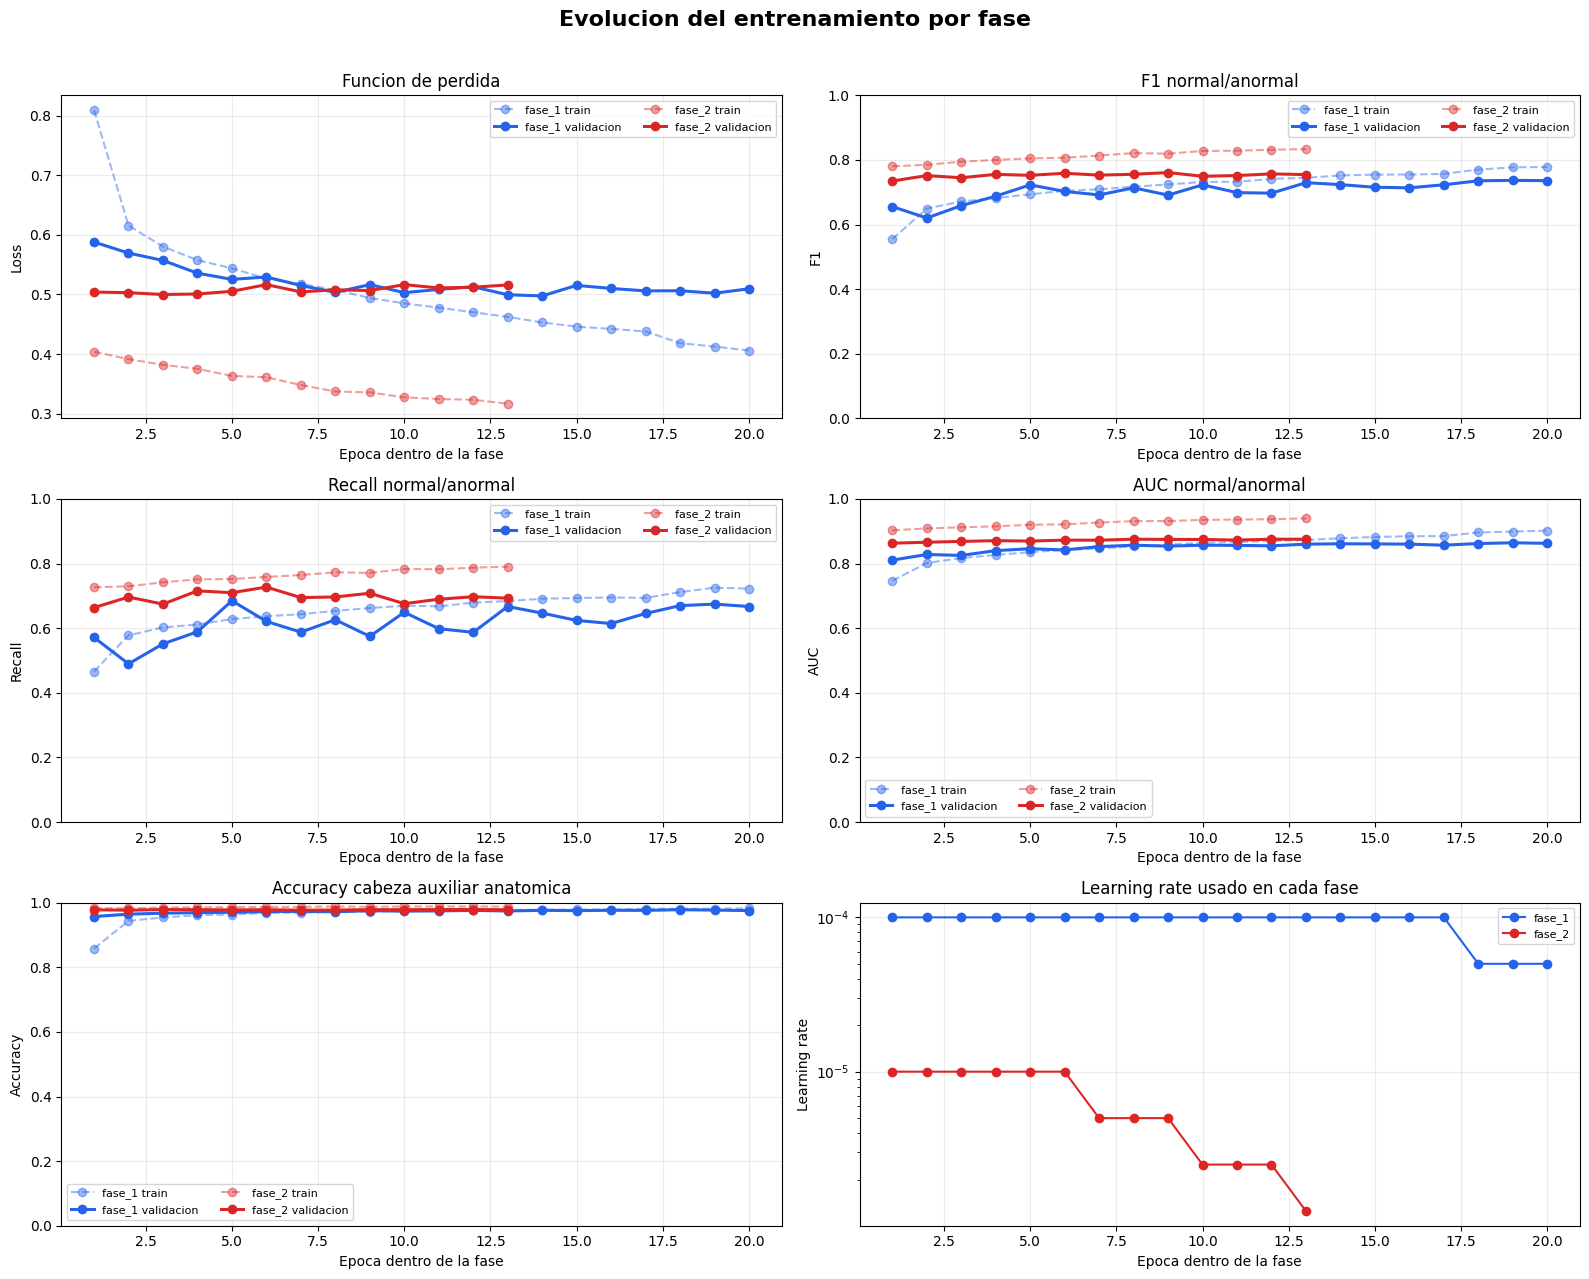

In [ ]:
# Funcion que crea el optimizador segun la fase del entrenamiento
def crear_optimizador(fase):

    # Fase 1: Seleccionamos los parámetros y usamos Adam con la tasa de aprendizaje y regularización de peso definidas
    if fase == 'fase_1':
        params = [p for p in modelo.parameters() if p.requires_grad]
        return torch.optim.AdamW(params, lr=TASA_APRENDIZAJE, weight_decay=REGULARIZACION_PESO) # regularización de peso para evitar sobreajuste, AdamW es una variante de Adam que maneja mejor la regularización de peso.

    # Fase 2: entrenamos todo ek modelo, pero no el backbone aprende más lento que  las cabezas para no perder lo aprendido en ImageNet
    return torch.optim.AdamW([
        {'params': modelo.features.parameters(), 'lr': TASA_APRENDIZAJE_BACKBONE},
        {'params': modelo.abnormal_head.parameters(), 'lr': TASA_APRENDIZAJE},
        {'params': modelo.body_part_head.parameters(), 'lr': TASA_APRENDIZAJE},
        {'params': modelo.body_part_embedding.parameters(), 'lr': TASA_APRENDIZAJE},
    ], weight_decay=REGULARIZACION_PESO)


# Para modificar automaticamente el lr durante el entrenamiento
def crear_scheduler(optimizador):
    # ReduceLROnPlateau reduce el learning rate cuando una métrica deja de mejorar, ideal cuando no sabemos cuando decaerá el aprendizaje
    return torch.optim.lr_scheduler.ReduceLROnPlateau( 
        optimizador,
        mode='min',             # minimizamos métrica
        patience=PACIENCIA_LR,  # número de épocas sin mejora antes de reducir el lr
        factor=FACTOR_LR,       # factor de reducción del lr
    )
criterio_anormalidad = nn.CrossEntropyLoss()
criterio_anatomia = nn.CrossEntropyLoss()


def ejecutar_epoca(loader, entrenando: bool): # Si entrenado = false validación
    modelo.train(entrenando)

    perdidas, etiquetas_reales, etiquetas_predichas, probabilidades_anormal = [], [], [], []
    aciertos_parte_anatomica = 0
    total_imagenes = 0

    # Recorremos el DataLoader batch a batch y movemos las imágenes y etiquetas a gpu o cpu
    for imagenes, etiquetas_anormalidad, etiquetas_anatomia in loader: 
        imagenes = imagenes.to(DISPOSITIVO)
        etiquetas_anormalidad = etiquetas_anormalidad.to(DISPOSITIVO)
        etiquetas_anatomia = etiquetas_anatomia.to(DISPOSITIVO)

        # Si entreando es True se calculan gradientes, sino no (validación)
        with torch.set_grad_enabled(entrenando):
            # Pasamos las imágenes y las etiqeutas abatomia por el modelo y obtenemos las salidas
            salida_anormalidad, salida_anatomia = modelo(imagenes, etiquetas_anatomia)

            # Funciones de pérdida
            perdida_principal = criterio_anormalidad(salida_anormalidad, etiquetas_anormalidad)
            perdida_auxiliar = criterio_anatomia(salida_anatomia, etiquetas_anatomia)
            perdida_total = perdida_principal + PESO_PERDIDA_ANATOMIA * perdida_auxiliar

            # Si estamos en train, borramos los gardientes acumulados, hacemos backpropagation y actualizamos los pesos con el optimizador.º
            if entrenando:  
                optimizador.zero_grad()
                perdida_total.backward()
                optimizador.step()

        # Convertimos logits (salidas) normal/anormal en probabilidad de clase anormal. Devuelve la prob de cada clase
        prob_anormal = torch.softmax(salida_anormalidad, dim=1)[:, 1]

        # Convertimos probabilidad en etiqueta binaria usando el umbral actual.
        pred_anormal = (prob_anormal >= UMBRAL_DECISION).long()  # .long() convierte el booleano a entero (0 o 1)

        # Guardamos pérdidad del batch en CPU para calcular metricas con sklearn.
        perdidas.append(float(perdida_total.detach().cpu()))

        # Añadimos etiquetas y probabilidades a las listas:
        etiquetas_reales.extend(etiquetas_anormalidad.detach().cpu().numpy().tolist())
        etiquetas_predichas.extend(pred_anormal.detach().cpu().numpy().tolist())
        probabilidades_anormal.extend(prob_anormal.detach().cpu().numpy().tolist())

        pred_anatomia = salida_anatomia.argmax(dim=1)
        aciertos_parte_anatomica += int((pred_anatomia == etiquetas_anatomia).sum().detach().cpu())
        total_imagenes += len(etiquetas_anormalidad)

    # Creamos diccionario con las métricas de la época
    metricas = {
        "loss": float(np.mean(perdidas)),
        "accuracy": accuracy_score(etiquetas_reales, etiquetas_predichas),
        "balanced_accuracy": balanced_accuracy_score(etiquetas_reales, etiquetas_predichas),
        "precision": precision_score(etiquetas_reales, etiquetas_predichas, zero_division=0),
        "recall": recall_score(etiquetas_reales, etiquetas_predichas, zero_division=0),
        "f1": f1_score(etiquetas_reales, etiquetas_predichas, zero_division=0),
        "auc": roc_auc_score(etiquetas_reales, probabilidades_anormal)
        if len(set(etiquetas_reales)) > 1
        else np.nan,
        "kappa": cohen_kappa_score(etiquetas_reales, etiquetas_predichas),
        "body_part_acc": aciertos_parte_anatomica / total_imagenes
        if total_imagenes
        else np.nan,
    }
    return metricas

# Extraemos la métrica que se usará para la selección del mejor modelo a partir de una fila del historial de entrenamiento, que contiene las métricas de cada época
def score_modelo(row):
    value = row[METRICA_SELECCION_MODELO]
    if pd.isna(value):
        return None
    return float(value)

# Comparamos el score actual con el mejor score encontrado hasta ahora para decidir si hay una mejora suficiente que justifique actualizar el mejor estado del modelo
def mejora_modelo(score_actual, mejor_score):
    if score_actual is None:  # Si el score actual es None no hay mejora
        return False
    if mejor_score is None:  # Si no hay un mejor score previo, el primer modelo válido se acepta como mejor
        return True
    if 'loss' in METRICA_SELECCION_MODELO:
        return (mejor_score - score_actual) > MEJORA_MINIMA # si el score actual es mejor que el mejor score previo devuelve True
    return (score_actual - mejor_score) > MEJORA_MINIMA     # devuelve True si el score actual es mejor que el mejor score previo


# Guardamos una copia en memoria del mejor estado, sin crear archivos de modelo en disco.
def copiar_estado_modelo():
    return {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}


# Cargamos un estado del modelo desde una copia en memoria, moviendo los tensores al dispositivo correspondiente.
def cargar_estado_modelo(estado):
    modelo.load_state_dict({k: v.to(DISPOSITIVO) for k, v in estado.items()})


# Hash sencillo para trazabilidad en la app sin depender de un archivo .pt.
def hash_estado_modelo(modelo):
    h = hashlib.sha256()
    for nombre, tensor in modelo.state_dict().items():
        h.update(nombre.encode())
        h.update(tensor.detach().cpu().numpy().tobytes())
    return h.hexdigest()[:12]


def entrenar_fase(nombre_fase, descripcion):
    global optimizador, mejor_score, mejor_estado_modelo, mejor_fase
    print('' + '=' * 70)
    print(descripcion)
    print('=' * 70)

    optimizador = crear_optimizador(nombre_fase)
    scheduler = crear_scheduler(optimizador)
    epocas_sin_mejora = 0

    for epoch in range(1, EPOCAS_MAX + 1):
        t0 = time.time()
        tr = ejecutar_epoca(cargador_train, entrenando=True)
        va = ejecutar_epoca(cargador_val_train, entrenando=False)
        lr_actual = optimizador.param_groups[0]['lr']

        row = {
            'fase': nombre_fase,
            'epoch': epoch,
            'lr': lr_actual,
            **{f'train_{k}': v for k, v in tr.items()},
            **{f'valid_{k}': v for k, v in va.items()},
        }
        historial.append(row)

        print(
            f"{nombre_fase} | epoch {epoch}/{EPOCAS_MAX} | "
            f"train loss {tr['loss']:.4f} f1 {tr['f1']:.3f} | "
            f"valid loss {va['loss']:.4f} f1 {va['f1']:.3f} auc {va['auc']:.3f} | "
            f"lr {lr_actual:.1e} | {time.time()-t0:.1f}s"
        )

        scheduler.step(va['loss'])
        score = score_modelo(row)

        if mejora_modelo(score, mejor_score):
            mejor_score = score
            mejor_estado_modelo = copiar_estado_modelo()
            mejor_fase = nombre_fase
            epocas_sin_mejora = 0
            print(f'  mejor estado actualizado ({METRICA_SELECCION_MODELO}={mejor_score:.4f})')
        else:
            epocas_sin_mejora += 1
            print(f'  sin mejora suficiente: {epocas_sin_mejora}/{PACIENCIA_EARLY_STOP}')
            if epocas_sin_mejora >= PACIENCIA_EARLY_STOP:
                print('Early stopping activado en esta fase')
                break

# Variables iniciales para el entrenamiento
historial = []
mejor_score = None
mejor_estado_modelo = None
mejor_fase = ''


# Fase 1: entrenamos solo las cabezas y las últimas capas del backbone
congelar_backbone_parcial(modelo)
print('Parametros fase 1:', contar_parametros(modelo))
entrenar_fase('fase_1', 'Fase 1: cabezales + ultimos bloques de EfficientNet')


# Fase 2: la segunda fase parte del mejor estado encontrado hasta ahora, sin guardar archivos de modelo en disco.
if mejor_estado_modelo is not None:
    cargar_estado_modelo(mejor_estado_modelo)

descongelar_todo(modelo)
print('Parametros fase 2:', contar_parametros(modelo))
entrenar_fase('fase_2', 'Fase 2: fine-tuning completo con learning rate bajo en backbone')

# Recupero el mejor estado global antes de optimizar el umbral.
if mejor_estado_modelo is None:
    raise RuntimeError('No se ha encontrado ningun estado valido del modelo. Revisa el entrenamiento.')

cargar_estado_modelo(mejor_estado_modelo)
modelo.eval()


def obtener_probabilidades(loader):
    y_true, y_prob = [], []
    modelo.eval()
    with torch.no_grad():
        for x, y_abn, y_bp in loader:
            x = x.to(DISPOSITIVO)
            y_bp = y_bp.to(DISPOSITIVO)
            out_abn, _ = modelo(x, y_bp)
            prob = torch.softmax(out_abn, dim=1)[:, 1].detach().cpu().numpy()
            y_true.extend(y_abn.numpy().tolist())
            y_prob.extend(prob.tolist())
    return np.array(y_true), np.array(y_prob)


def buscar_umbral(y_true, y_prob, objetivo='f1'):
    mejor_umbral = 0.50
    mejor_valor = -1
    for umbral in np.linspace(0.05, 0.95, 181):
        pred = (y_prob >= umbral).astype(int)
        if objetivo == 'recall':
            valor = recall_score(y_true, pred, zero_division=0)
        elif objetivo == 'balanced_accuracy':
            valor = balanced_accuracy_score(y_true, pred)
        else:
            valor = f1_score(y_true, pred, zero_division=0)
        if valor > mejor_valor:
            mejor_valor = valor
            mejor_umbral = float(umbral)
    return mejor_umbral, mejor_valor

y_val_umbral, prob_val_umbral = obtener_probabilidades(cargador_val_train)
umbral_optimo, valor_umbral = buscar_umbral(y_val_umbral, prob_val_umbral, OBJETIVO_UMBRAL)
UMBRAL_DECISION = umbral_optimo
MODEL_HASH = hash_estado_modelo(modelo)

print(f'Umbral optimizado en validacion interna: {UMBRAL_DECISION:.3f} ({OBJETIVO_UMBRAL}={valor_umbral:.4f})')
print(f'Mejor estado segun {METRICA_SELECCION_MODELO}: {mejor_score:.4f} ({mejor_fase})')
print('Hash del modelo:', MODEL_HASH)


# Guardamos una unica copia final del modelo.
# Durante el entrenamiento no se han creado guardados intermedios.
modelo_final = {
    'model_state_dict': {k: v.detach().cpu() for k, v in modelo.state_dict().items()},
    'umbral_decision': float(UMBRAL_DECISION),
    'model_hash': MODEL_HASH,
    'version_modelo': VERSION_MODELO,
    'partes_anatomicas': PARTES_ANATOMICAS,
    'tam_imagen': TAM_IMAGEN,
    'metrica_seleccion_modelo': METRICA_SELECCION_MODELO,
    'mejor_score': float(mejor_score) if mejor_score is not None else None,
    'mejor_fase': mejor_fase,
}
torch.save(modelo_final, RUTA_MODELO_FINAL)
print('Modelo final guardado en:', RUTA_MODELO_FINAL)

historial_df = pd.DataFrame(historial)
display(historial_df)

Figura guardada en: outputs/figuras/train_par_1_perdida_lr.png


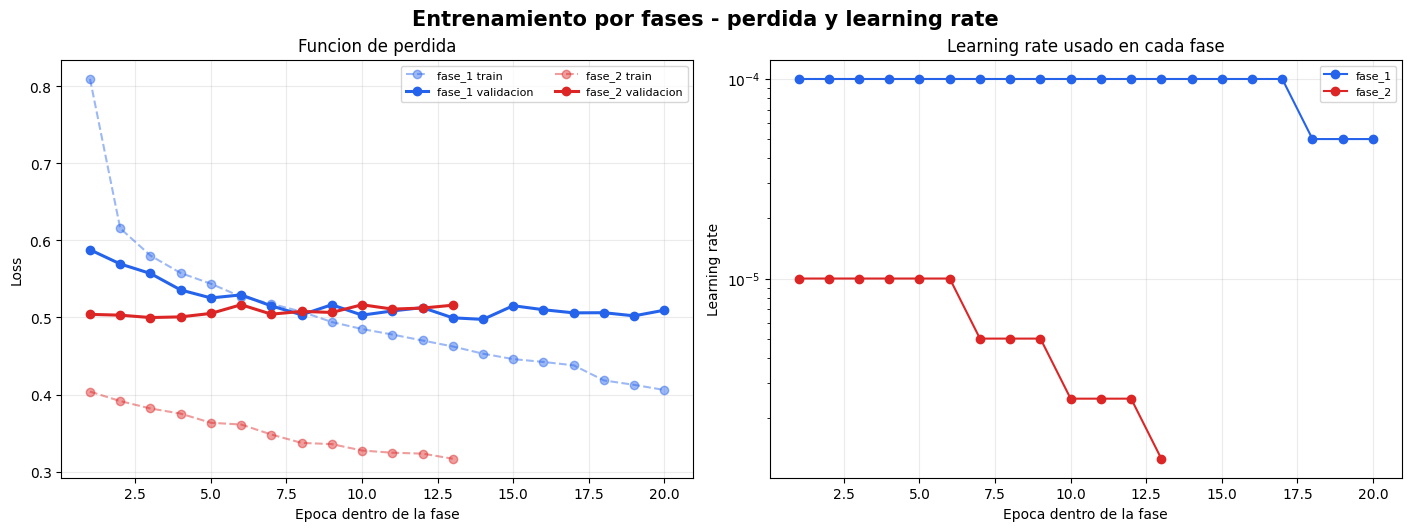

Figura guardada en: outputs/figuras/train_par_2_f1_recall.png


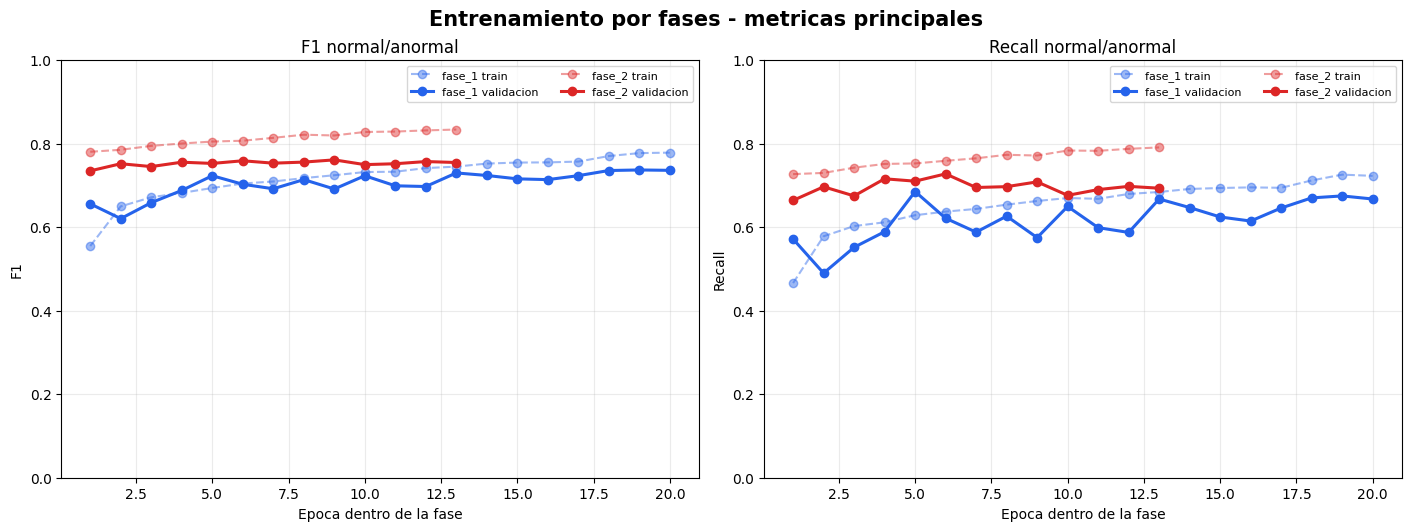

Figura guardada en: outputs/figuras/train_par_3_auc_auxiliar.png


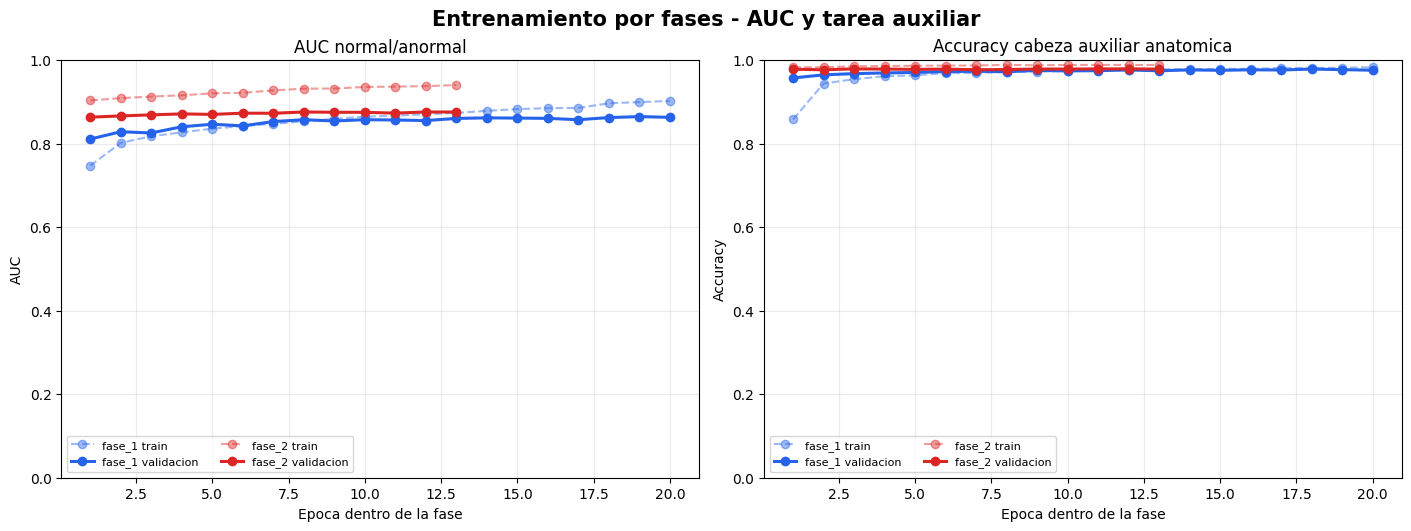

In [48]:

# Graficas de entrenamiento y validacion interna.
# Separamos las figuras en parejas para poder exportarlas en mejor tamaño a LaTeX.
colores_fase = {'fase_1': '#2563eb', 'fase_2': '#dc2626'}

def pintar_train_valid(ax, metrica, titulo, ylabel, ylim=None):
    for fase, df_fase in historial_df.groupby('fase'):
        color = colores_fase.get(fase, None)
        ax.plot(
            df_fase['epoch'], df_fase[f'train_{metrica}'],
            linestyle='--', marker='o', color=color, alpha=0.45,
            label=f'{fase} train'
        )
        ax.plot(
            df_fase['epoch'], df_fase[f'valid_{metrica}'],
            linestyle='-', marker='o', color=color, linewidth=2.2,
            label=f'{fase} validacion'
        )
    ax.set_title(titulo)
    ax.set_xlabel('Epoca dentro de la fase')
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(*ylim)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, ncol=2)


def guardar_figura(figura, nombre_archivo):
    ruta_figura = os.path.join(DIR_FIGURAS, nombre_archivo)
    figura.savefig(ruta_figura, dpi=220, bbox_inches='tight')
    print('Figura guardada en:', ruta_figura)


# Pareja 1: perdida y learning rate.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), constrained_layout=True)
fig.suptitle('Entrenamiento por fases - perdida y learning rate', fontsize=15, fontweight='bold')

pintar_train_valid(axes[0], 'loss', 'Funcion de perdida', 'Loss')
for fase, df_fase in historial_df.groupby('fase'):
    color = colores_fase.get(fase, None)
    axes[1].plot(df_fase['epoch'], df_fase['lr'], marker='o', color=color, label=fase)
axes[1].set_title('Learning rate usado en cada fase')
axes[1].set_xlabel('Epoca dentro de la fase')
axes[1].set_ylabel('Learning rate')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

guardar_figura(fig, 'train_par_1_perdida_lr.png')
plt.show()

# Pareja 2: metricas principales dependientes del umbral.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), constrained_layout=True)
fig.suptitle('Entrenamiento por fases - metricas principales', fontsize=15, fontweight='bold')

pintar_train_valid(axes[0], 'f1', 'F1 normal/anormal', 'F1', (0, 1))
pintar_train_valid(axes[1], 'recall', 'Recall normal/anormal', 'Recall', (0, 1))

guardar_figura(fig, 'train_par_2_f1_recall.png')
plt.show()

# Pareja 3: AUC de la tarea principal y accuracy de la cabeza auxiliar.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), constrained_layout=True)
fig.suptitle('Entrenamiento por fases - AUC y tarea auxiliar', fontsize=15, fontweight='bold')

pintar_train_valid(axes[0], 'auc', 'AUC normal/anormal', 'AUC', (0, 1))
pintar_train_valid(axes[1], 'body_part_acc', 'Accuracy cabeza auxiliar anatomica', 'Accuracy', (0, 1))

guardar_figura(fig, 'train_par_3_auc_auxiliar.png')
plt.show()


## G. Evaluación final sobre `valid` oficial de MURA

Una vez fijado el mejor estado del modelo y el umbral de decisión con la validación interna, se recarga el modelo y se evalúa sobre el `valid` oficial de MURA. Esta es la evaluación final del notebook y la base de las salidas que leerá la app Streamlit.

La evaluación se separa en dos partes. Primero se evalúa la cabeza principal, que es la salida normal/anormal usada por el sistema de vigilancia. Para esta tarea se calculan `accuracy`, `balanced accuracy`, `precision`, `recall`, `F1`, `AUC`, `average precision`, matriz de confusión, curva ROC, curva *precision-recall* y distribución de probabilidades. En el contexto clínico del TFG, el `recall` es especialmente relevante porque interesa no dejar pasar anormalidades; la tasa de falsos negativos derivada de esa sensibilidad se puede interpretar como un riesgo operativo.

Después se evalúa la cabeza auxiliar de parte anatómica. Esta salida no se usa como resultado principal en la app, pero sirve para comprobar que la tarea secundaria aprende información anatómica real durante el entrenamiento. Para ello se calcula la accuracy global de parte anatómica, un reporte por clase y una matriz de confusión anatómica.

El umbral usado aquí viene de la validación interna, no del `valid` oficial. Así la evaluación final sigue siendo honesta.


Umbral usado en valid MURA oficial: 0.5
              precision    recall  f1-score   support

      normal       0.76      0.89      0.82      1667
    abnormal       0.86      0.70      0.77      1530

    accuracy                           0.80      3197
   macro avg       0.81      0.79      0.80      3197
weighted avg       0.81      0.80      0.80      3197

Matriz de confusion:
[[1486  181]
 [ 462 1068]]
Balanced accuracy: 0.7947304656715716
Cohen kappa: 0.5939433756646637
AUC: 0.8593724392376427
Average precision: 0.8706467910859003


,file_id,file_name,size,added_at,md5_hash,split,body_part,patient_id,study,true_label,...,local_path,downloaded,body_part_idx,study_id,body_part_fmt,abnormality_probability,predicted_label,predicted_body_part_idx,predicted_body_part,inference_time_ms
0,gcvw-8sbb61dwy.gO5IC4xwWxAUUsDasTmUKg,valid/XR_SHOULDER/patient11735/study1_positive...,115318,2026-03-07 17:06:43.175000,ejnNN6MEckGAIZjC3zHl6w==,valid,SHOULDER,patient11735,study1_positive,1,...,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True,5,XR_SHOULDER_patient11735_study1_positive,XR_SHOULDER,0.999995,1,5,SHOULDER,0.41
1,gcvw-8sbb61dwy.NH2qnAXQBhm55rM_goRkJg,valid/XR_SHOULDER/patient11738/study1_positive...,79333,2026-03-07 17:06:43.175000,XnHdh7XC3vvfw0sjDNR6Pw==,valid,SHOULDER,patient11738,study1_positive,1,...,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True,5,XR_SHOULDER_patient11738_study1_positive,XR_SHOULDER,0.950133,1,5,SHOULDER,0.41
2,gcvw-8sbb61dwy.Kw2qYuOi4i4t3hzKFVGDbg,valid/XR_SHOULDER/patient11770/study1_negative...,56967,2026-03-07 17:06:43.175000,hGk5ZhYMC1+YqtZVwxJZGQ==,valid,SHOULDER,patient11770,study1_negative,0,...,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True,5,XR_SHOULDER_patient11770_study1_negative,XR_SHOULDER,0.029032,0,5,SHOULDER,0.41
3,gcvw-8sbb61dwy.Ccz6BtJ7ZCW24r8dwPSsbQ,valid/XR_SHOULDER/patient11794/study1_negative...,43658,2026-03-07 17:06:43.175000,aJ1anfQwcg4QxhnkArXE9Q==,valid,SHOULDER,patient11794,study1_negative,0,...,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True,5,XR_SHOULDER_patient11794_study1_negative,XR_SHOULDER,0.021839,0,5,SHOULDER,0.41
4,gcvw-8sbb61dwy.GPfYLrhLWxUKiCZkwQtkVQ,valid/XR_SHOULDER/patient11798/study1_negative...,54974,2026-03-07 17:06:43.175000,M+IKxg5R3BTb3ZErLmvIuw==,valid,SHOULDER,patient11798,study1_negative,0,...,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,True,5,XR_SHOULDER_patient11798_study1_negative,XR_SHOULDER,0.027188,0,5,SHOULDER,0.41


Figura guardada en: outputs/figuras/valid_principal_par_1_matriz_roc.png


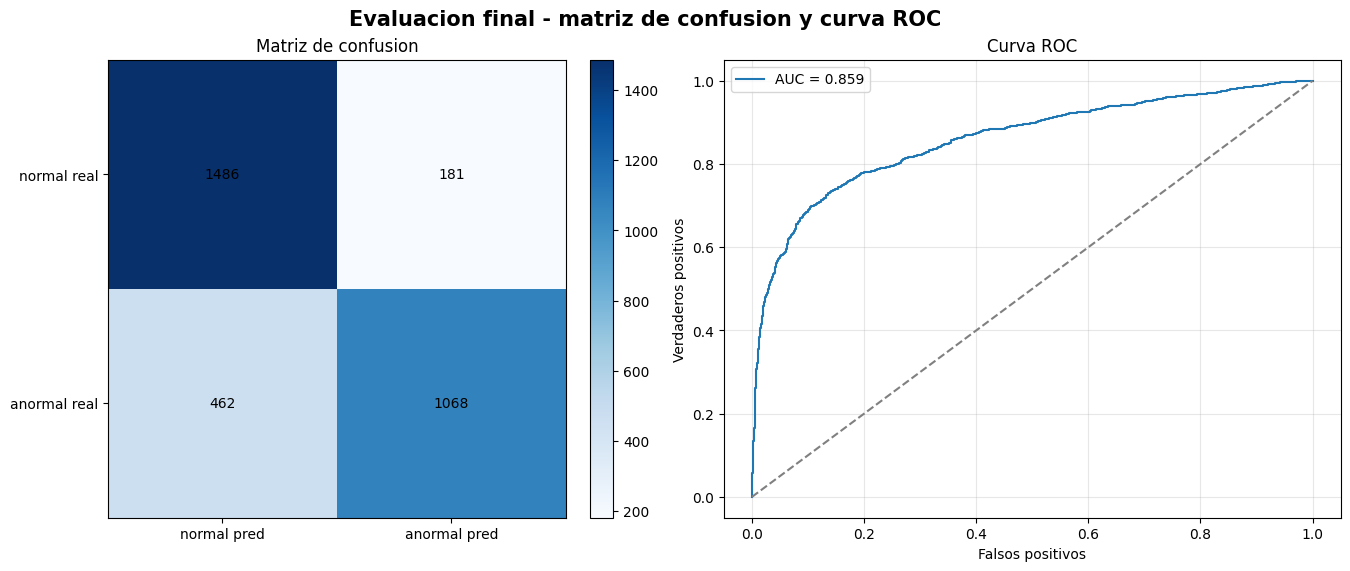

Figura guardada en: outputs/figuras/valid_principal_par_2_pr_boxplot.png


/var/folders/pc/p19thmms0wj9dgrcf0jt5mlc0000gn/T/ipykernel_6223/3240881526.py:113: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot_prob = axes[1].boxplot(


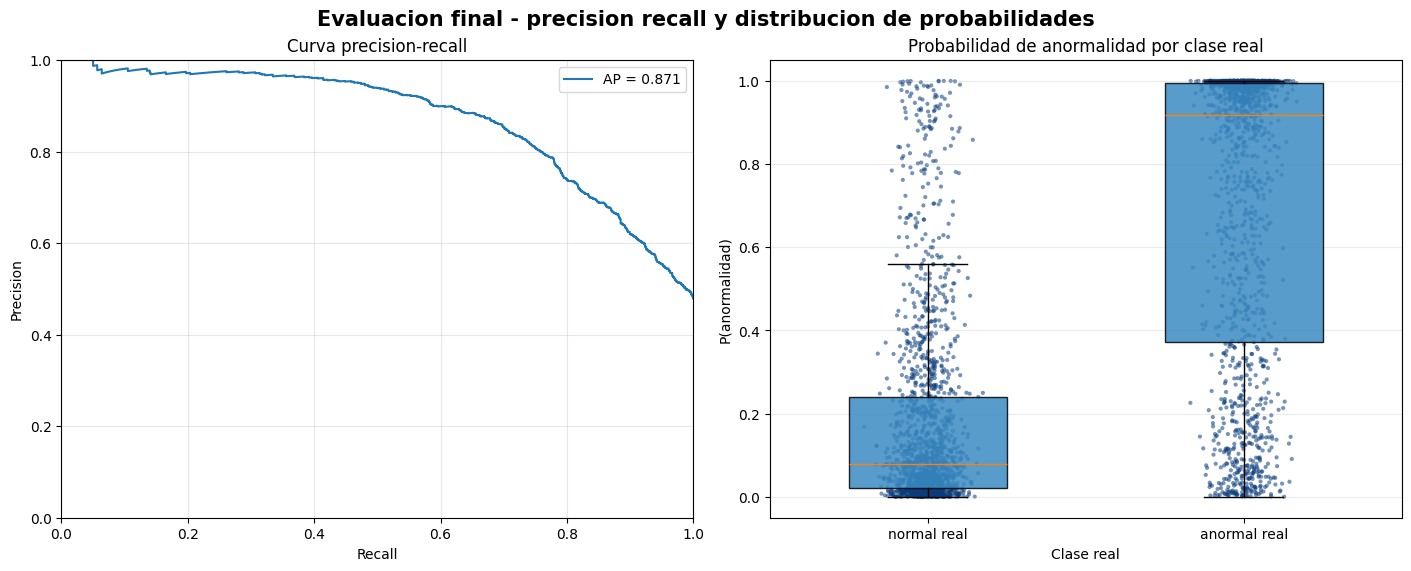

In [49]:
# Cargamos en el modelo los pesos del mejor estado encontrado durante el train
cargar_estado_modelo(mejor_estado_modelo)
modelo.eval()  # Modo evaluación 
print('Umbral usado en valid MURA oficial:', round(UMBRAL_DECISION, 3))

# Creamos un DataLoader para recorrer el valid oficial de MURA sin mezclar las imagenes.
dataset_valid_mura = DatasetMURA(datos_valid, transformacion_valid)
cargador_valid_mura = DataLoader(dataset_valid_mura, batch_size=TAM_LOTE, shuffle=False, num_workers=0)

filas_predicciones_imagen = []
indice_inicio_batch = 0

# No calculamos gradientes porque aqui solo hacemos inferencia/evaluacion.
with torch.no_grad():
    for imagenes, _, indices_anatomia in cargador_valid_mura:
        instante_inicio = time.perf_counter()

        imagenes = imagenes.to(DISPOSITIVO)
        indices_anatomia = indices_anatomia.to(DISPOSITIVO)

        # El modelo devuelve dos salidas: normal/anormal y parte anatomica.
        salida_anormalidad, salida_anatomia = modelo(imagenes, indices_anatomia)

        tiempo_por_imagen_ms = (time.perf_counter() - instante_inicio) * 1000 / len(imagenes)
        probabilidades_anormalidad = torch.softmax(salida_anormalidad, dim=1)[:, 1].detach().cpu().numpy()
        etiquetas_predichas = (probabilidades_anormalidad >= UMBRAL_DECISION).astype(int)
        indices_anatomia_predichos = salida_anatomia.argmax(dim=1).detach().cpu().numpy()

        # Recuperamos las filas originales de MURA que corresponden a este batch.
        metadatos_batch = datos_valid.iloc[indice_inicio_batch:indice_inicio_batch + len(imagenes)].copy()

        for posicion_batch, (_, fila_mura) in enumerate(metadatos_batch.iterrows()):
            filas_predicciones_imagen.append({
                **fila_mura.to_dict(),
                'abnormality_probability': float(probabilidades_anormalidad[posicion_batch]),
                'predicted_label': int(etiquetas_predichas[posicion_batch]),
                'predicted_body_part_idx': int(indices_anatomia_predichos[posicion_batch]),
                'predicted_body_part': PARTES_ANATOMICAS[int(indices_anatomia_predichos[posicion_batch])],
                'inference_time_ms': round(float(tiempo_por_imagen_ms), 2),
            })

        indice_inicio_batch += len(imagenes)

# Tabla a nivel de imagen: se mantiene en memoria para evaluar y crear despues la tabla base de la app.
predicciones_imagen = pd.DataFrame(filas_predicciones_imagen)

etiquetas_reales_valid = predicciones_imagen['true_label'].astype(int)
etiquetas_predichas_valid = predicciones_imagen['predicted_label'].astype(int)
probabilidades_valid = predicciones_imagen['abnormality_probability'].astype(float)

print(classification_report(etiquetas_reales_valid, etiquetas_predichas_valid, target_names=['normal', 'abnormal'], zero_division=0))
print('Matriz de confusion:')
print(confusion_matrix(etiquetas_reales_valid, etiquetas_predichas_valid))
print('Balanced accuracy:', balanced_accuracy_score(etiquetas_reales_valid, etiquetas_predichas_valid))
print('Cohen kappa:', cohen_kappa_score(etiquetas_reales_valid, etiquetas_predichas_valid))
print('AUC:', roc_auc_score(etiquetas_reales_valid, probabilidades_valid))
print('Average precision:', average_precision_score(etiquetas_reales_valid, probabilidades_valid))
display(predicciones_imagen.head())


# Graficas de evaluacion final sobre el valid oficial de MURA.
# Separamos las figuras en parejas para exportarlas mejor a LaTeX.
matriz_confusion = confusion_matrix(etiquetas_reales_valid, etiquetas_predichas_valid)
falsos_positivos, verdaderos_positivos, _ = roc_curve(etiquetas_reales_valid, probabilidades_valid)
precision_curve, recall_curve, _ = precision_recall_curve(etiquetas_reales_valid, probabilidades_valid)
auc_valid = roc_auc_score(etiquetas_reales_valid, probabilidades_valid)
average_precision_valid = average_precision_score(etiquetas_reales_valid, probabilidades_valid)

# Pareja 1: matriz de confusion y curva ROC.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), constrained_layout=True)
fig.suptitle('Evaluacion final - matriz de confusion y curva ROC', fontsize=15, fontweight='bold')

im = axes[0].imshow(matriz_confusion, cmap='Blues', aspect='equal')
axes[0].set_box_aspect(1)
axes[0].set_title('Matriz de confusion')
axes[0].set_xticks([0, 1], labels=['normal pred', 'anormal pred'])
axes[0].set_yticks([0, 1], labels=['normal real', 'anormal real'])
for fila in range(2):
    for columna in range(2):
        axes[0].text(columna, fila, matriz_confusion[fila, columna], ha='center', va='center', color='black')
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].plot(falsos_positivos, verdaderos_positivos, label=f'AUC = {auc_valid:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('Falsos positivos')
axes[1].set_ylabel('Verdaderos positivos')
axes[1].legend()
axes[1].grid(alpha=0.3)

guardar_figura(fig, 'valid_principal_par_1_matriz_roc.png')
plt.show()

prob_normal_real = probabilidades_valid[etiquetas_reales_valid == 0].to_numpy()
prob_anormal_real = probabilidades_valid[etiquetas_reales_valid == 1].to_numpy()

azul_matriz_confusion = plt.cm.Blues(0.65)
azul_puntos_muestra = plt.cm.Blues(0.95)

# Pareja 2: precision-recall y distribucion de probabilidades por clase real.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), constrained_layout=True)
fig.suptitle('Evaluacion final - precision recall y distribucion de probabilidades', fontsize=15, fontweight='bold')

axes[0].plot(recall_curve, precision_curve, label=f'AP = {average_precision_valid:.3f}')
axes[0].set_title('Curva precision-recall')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3)

boxplot_prob = axes[1].boxplot(
    [prob_normal_real, prob_anormal_real],
    labels=['normal real', 'anormal real'],
    patch_artist=True,
    showfliers=False,
    widths=0.50,
)
for caja in boxplot_prob['boxes']:
    caja.set_facecolor(azul_matriz_confusion)
    caja.set_alpha(0.85)

generador_jitter = np.random.default_rng(SEMILLA)
for posicion, valores in [(1, prob_normal_real), (2, prob_anormal_real)]:
    x_jitter = generador_jitter.normal(posicion, 0.055, size=len(valores))
    axes[1].scatter(x_jitter, valores, s=9, alpha=0.55, color=azul_puntos_muestra, edgecolors='none')
axes[1].set_title('Probabilidad de anormalidad por clase real')
axes[1].set_xlabel('Clase real')
axes[1].set_ylabel('P(anormalidad)')
axes[1].grid(axis='y', alpha=0.25)

guardar_figura(fig, 'valid_principal_par_2_pr_boxplot.png')
plt.show()


Accuracy cabeza auxiliar parte anatomica: 0.964
Reporte por parte anatomica:
              precision    recall  f1-score   support

       ELBOW       0.94      0.98      0.96       465
      FINGER       0.97      0.97      0.97       461
     FOREARM       0.95      0.86      0.90       301
        HAND       0.96      0.97      0.97       460
     HUMERUS       1.00      0.90      0.95       288
    SHOULDER       0.98      1.00      0.99       563
       WRIST       0.96      0.99      0.97       659

    accuracy                           0.96      3197
   macro avg       0.97      0.95      0.96      3197
weighted avg       0.96      0.96      0.96      3197



,parte_anatomica,accuracy_auxiliar
0,ELBOW,0.984946
1,FINGER,0.965293
2,FOREARM,0.860465
3,HAND,0.971739
4,HUMERUS,0.899306
5,SHOULDER,1.000000
6,WRIST,0.987860


Figura guardada en: outputs/figuras/valid_auxiliar_par_1_matriz_accuracy.png


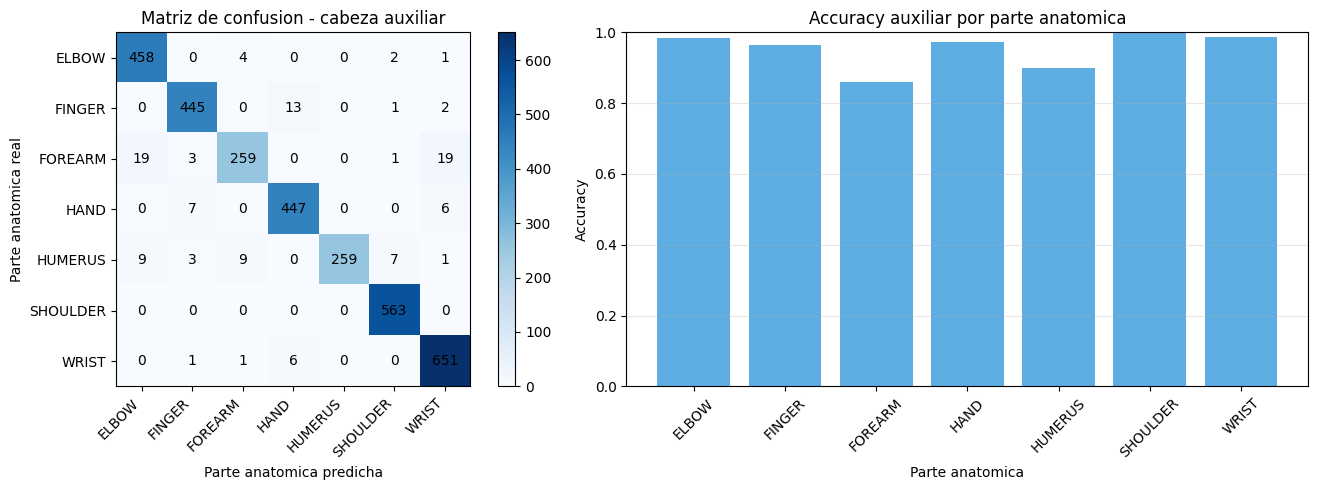

In [50]:
# Evaluacion final de la cabeza auxiliar: parte anatomica.
# La app no usa esta salida como prediccion principal, pero nos sirve para validar
# que la tarea secundaria realmente aprende informacion anatomica.
etiquetas_anatomia_reales = predicciones_imagen['body_part_idx'].astype(int)
etiquetas_anatomia_predichas = predicciones_imagen['predicted_body_part_idx'].astype(int)
indices_partes = list(range(len(PARTES_ANATOMICAS)))

accuracy_anatomia = accuracy_score(etiquetas_anatomia_reales, etiquetas_anatomia_predichas)
print('Accuracy cabeza auxiliar parte anatomica:', round(accuracy_anatomia, 4))
print('Reporte por parte anatomica:')
print(classification_report(
    etiquetas_anatomia_reales,
    etiquetas_anatomia_predichas,
    labels=indices_partes,
    target_names=PARTES_ANATOMICAS,
    zero_division=0,
))

matriz_confusion_anatomia = confusion_matrix(
    etiquetas_anatomia_reales,
    etiquetas_anatomia_predichas,
    labels=indices_partes,
)

tabla_accuracy_anatomia = pd.DataFrame({
    'parte_anatomica': predicciones_imagen['body_part'],
    'acierto_auxiliar': etiquetas_anatomia_reales.to_numpy() == etiquetas_anatomia_predichas.to_numpy(),
})
tabla_accuracy_anatomia = (
    tabla_accuracy_anatomia
    .groupby('parte_anatomica')['acierto_auxiliar']
    .mean()
    .reindex(PARTES_ANATOMICAS)
    .reset_index()
)
tabla_accuracy_anatomia.columns = ['parte_anatomica', 'accuracy_auxiliar']
display(tabla_accuracy_anatomia)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

im = axes[0].imshow(matriz_confusion_anatomia, cmap='Blues')
axes[0].set_title('Matriz de confusion - cabeza auxiliar')
axes[0].set_xlabel('Parte anatomica predicha')
axes[0].set_ylabel('Parte anatomica real')
axes[0].set_xticks(indices_partes, labels=PARTES_ANATOMICAS, rotation=45, ha='right')
axes[0].set_yticks(indices_partes, labels=PARTES_ANATOMICAS)
for fila in indices_partes:
    for columna in indices_partes:
        valor = matriz_confusion_anatomia[fila, columna]
        axes[0].text(columna, fila, valor, ha='center', va='center', color='black')
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].bar(tabla_accuracy_anatomia['parte_anatomica'], tabla_accuracy_anatomia['accuracy_auxiliar'], color='#5DADE2')
axes[1].set_title('Accuracy auxiliar por parte anatomica')
axes[1].set_xlabel('Parte anatomica')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
guardar_figura(fig, 'valid_auxiliar_par_1_matriz_accuracy.png')
plt.show()


## H. Generación de salidas para la aplicación de vigilancia

La app no reentrena el modelo ni recalcula el entrenamiento. Su función es leer la tabla base generada por este notebook y usarla para simular la fase de vigilancia poscomercialización. Por eso, en esta sección se crean los artefactos que sí necesita la app: agregación por estudio, tabla base, imágenes anotadas y campos de trazabilidad como `trace_id`, `model_hash` o marcas temporales.

La app de vigilancia trabaja a nivel de estudio, no solo a nivel de imagen. Por eso se agregan las predicciones usando la probabilidad máxima de anormalidad entre las vistas de cada estudio. La etiqueta predicha a nivel de estudio usa el umbral aprendido en validación interna. La etiqueta real sigue siendo la referencia de MURA, y queda guardada para que la app pueda calcular métricas de vigilancia tras las revisiones manuales.

La tabla resultante deja preparada la estructura para que más adelante la app recoja *feedback* operativo del médico de AP o urgencias y calcule vigilancia y alertas. Esta sección es, por tanto, el puente entre el notebook y la aplicación Streamlit.


In [51]:
# Creamos una copia visual de la radriografía con la predicció del modelo encima 
def crear_imagen_analizada(fila_estudio, ruta_salida):
    imagen_original = Image.open(fila_estudio['local_path']).convert('L')
    imagen_original = ImageOps.autocontrast(imagen_original).convert('RGB')
    imagen_original.thumbnail((512, 512))

    alto_texto = 44
    lienzo = Image.new('RGB', (imagen_original.width, imagen_original.height + alto_texto), (0, 0, 0))
    lienzo.paste(imagen_original, (0, 0))

    predice_anormal = fila_estudio['predicted_label'] == 1
    color_prediccion = (210, 60, 60) if predice_anormal else (50, 170, 90)
    texto_prediccion = f"P(anom): {fila_estudio['abnormality_probability']*100:.1f}% | {'ANORMAL' if predice_anormal else 'NORMAL'}"

    dibujo = ImageDraw.Draw(lienzo)
    dibujo.rectangle([0, 0, lienzo.width - 1, lienzo.height - 1], outline=color_prediccion, width=8)
    dibujo.rectangle([0, imagen_original.height, lienzo.width, lienzo.height], fill=(0, 0, 0))
    dibujo.text((10, imagen_original.height + 12), texto_prediccion, fill=color_prediccion)

    os.makedirs(os.path.dirname(ruta_salida), exist_ok=True)
    lienzo.save(ruta_salida)
    return ruta_salida

# La app trabaja a nivel de estudio. Si un estudio tiene varias imagenes/vistas,
# nos quedamos con la vista que tiene mayor probabilidad de anormalidad.
indice_imagen_mas_anormal_por_estudio = predicciones_imagen.groupby('study_id')['abnormality_probability'].idxmax()
estudios_app = predicciones_imagen.loc[indice_imagen_mas_anormal_por_estudio].copy()
estudios_app = estudios_app.sort_values(['body_part', 'patient_id', 'study']).reset_index(drop=True)

# Recalculamos la etiqueta predicha a nivel de estudio usando el umbral final.
estudios_app['predicted_label'] = (estudios_app['abnormality_probability'] >= UMBRAL_DECISION).astype(int)

# Fechas ordenadas para que los casos tengan una secuencia reproducible dentro de la app.
fecha_inicio_simulada = datetime(2025, 1, 6, 8, 0, 0)
tiempos_recepcion = [
    fecha_inicio_simulada + timedelta(minutes=18 * numero_caso)
    for numero_caso in range(len(estudios_app))
]
estudios_app['timestamp_received'] = [fecha.strftime('%Y-%m-%dT%H:%M:%SZ') for fecha in tiempos_recepcion]
# Identificadores seudonimizados y trazabilidad del modelo.
estudios_app['patient_id_hash'] = estudios_app['patient_id'].apply(lambda x: hashlib.md5(str(x).encode()).hexdigest()[:12])
estudios_app['trace_id'] = estudios_app['study_id'].apply(lambda x: hashlib.md5(str(x).encode()).hexdigest()[:16])
estudios_app['model_hash'] = MODEL_HASH if 'MODEL_HASH' in globals() else hash_estado_modelo(modelo)

# Creamos una imagen anotada por cada estudio para que Streamlit muestre radiografia original y salida analizada.
rutas_imagenes_analizadas = []
for _, fila_estudio in estudios_app.iterrows():
    nombre_archivo_seguro = str(fila_estudio['study_id']).replace('/', '_') + '.png'
    ruta_imagen_analizada = os.path.join(DIR_IMAGENES_ANALIZADAS, nombre_archivo_seguro)
    rutas_imagenes_analizadas.append(crear_imagen_analizada(fila_estudio, ruta_imagen_analizada))

def ruta_relativa_repo(ruta):
    return str(Path(ruta).resolve().relative_to(DIR_REPO))

estudios_app['image_path'] = estudios_app['local_path'].apply(ruta_relativa_repo)
estudios_app['analyzed_image_path'] = [ruta_relativa_repo(ruta) for ruta in rutas_imagenes_analizadas]
estudios_app['body_part'] = estudios_app['body_part_fmt']

# Columnas finales que consume la app de vigilancia.
# No exportamos true_label a la app: MURA se usa para entrenar/validar el modelo,
# pero en la vigilancia el ground truth operativo lo introduce manualmente el medico de urgencias.
columnas_registro_inferencias = [
    'study_id', 'trace_id', 'patient_id_hash', 'body_part', 'image_path', 'analyzed_image_path',
    'abnormality_probability', 'predicted_label', 'inference_time_ms',
    'model_hash', 'timestamp_received'
]

# La app trabaja con nombres de columnas en espanol para que el contrato de datos
# sea facil de leer y defender en el TFG.
nombres_columnas_app = {
    'study_id': 'id_estudio',
    'trace_id': 'id_traza',
    'patient_id_hash': 'hash_paciente',
    'body_part': 'parte_anatomica',
    'image_path': 'ruta_imagen',
    'analyzed_image_path': 'ruta_imagen_analizada',
    'abnormality_probability': 'probabilidad_anormalidad',
    'predicted_label': 'etiqueta_predicha',
    'inference_time_ms': 'tiempo_inferencia_ms',
    'model_hash': 'hash_modelo',
    'timestamp_received': 'fecha_recepcion',
}

registro_inferencias = estudios_app[columnas_registro_inferencias].rename(columns=nombres_columnas_app).copy()
ruta_registro_inferencias = os.path.join(DIR_TABLAS, 'registro_inferencias_modelo.csv')
registro_inferencias.to_csv(ruta_registro_inferencias, index=False)

print('registro_inferencias_modelo.csv actualizado:', len(registro_inferencias), 'estudios')
print('Registro guardado en:', ruta_registro_inferencias)
display(registro_inferencias.head())


registro_inferencias_modelo.csv actualizado: 1199 estudios
Registro guardado en: outputs/tablas/registro_inferencias_modelo.csv


,id_estudio,id_traza,hash_paciente,parte_anatomica,ruta_imagen,ruta_imagen_analizada,probabilidad_anormalidad,etiqueta_predicha,tiempo_inferencia_ms,hash_modelo,fecha_recepcion
0,XR_ELBOW_patient11186_study1_positive,3d5888a075c2cbcd,779e84ae7a0a,XR_ELBOW,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,0.999966,1,0.30,a762fe86a14e,2025-01-06T08:00:00Z
1,XR_ELBOW_patient11189_study1_positive,e2a30e1235e3a2e8,49199d81835f,XR_ELBOW,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,0.999013,1,0.29,a762fe86a14e,2025-01-06T08:18:00Z
2,XR_ELBOW_patient11204_study1_negative,d3db8adfac07e557,f3536b82a81d,XR_ELBOW,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,0.057030,0,0.31,a762fe86a14e,2025-01-06T08:36:00Z
3,XR_ELBOW_patient11205_study1_negative,812bff5f9e86349f,4bc18cf0ff90,XR_ELBOW,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,0.005205,0,0.30,a762fe86a14e,2025-01-06T08:54:00Z
4,XR_ELBOW_patient11217_study1_negative,dbe9bc2fe200c651,f57bf6e79cb7,XR_ELBOW,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,/Users/emiliopesenti/Desktop/Practicas&TFG/TFG...,0.988362,1,0.31,a762fe86a14e,2025-01-06T09:12:00Z


## I. Relación entre este notebook y la app de vigilancia poscomercialización

Conviene separar claramente dos fases del sistema:

1. **Fase offline (este notebook).**  
   Aquí se entrena, valida y congela un modelo de deep learning sobre MURA. El resultado son métricas, predicciones y tablas exportadas.

2. **Fase de vigilancia poscomercialización (app Streamlit).**  
   La app carga casos, muestra la predicción del modelo ya entrenado, recoge un *ground truth* operativo o feedback manual del médico de urgencias, calcula métricas longitudinales, genera alertas, registra auditoría y produce informes de seguimiento.

Esta separación es importante para el TFG porque evita mezclar desarrollo del modelo con vigilancia operacional. El notebook no debe reentrenarse desde la app y la app no debe modificar el modelo: únicamente monitoriza su comportamiento a partir de predicciones ya generadas y del feedback posterior.

## J. Limitaciones del enfoque

Este notebook y la aplicación asociada deben entenderse como un **prototipo académico de vigilancia poscomercialización**, no como un producto sanitario real. Las principales limitaciones son las siguientes:

- **MURA no es BoneView.** Se usa como dataset académico de radiografías musculoesqueléticas reales, pero no reproduce el comportamiento ni la validación de un producto comercial.
- **La tarea es normal/anormal, no fractura específica.** MURA etiqueta anormalidad musculoesquelética y no un único diagnóstico clínico de fractura.
- **No existe integración real con PACS/RIS.** El flujo clínico se aproxima mediante tablas, CSV y una app de prototipo.
- **El feedback del médico de urgencias es simulado o manual.** No procede de un circuito asistencial real con trazabilidad clínica completa.
- **No hay validación clínica prospectiva.** Las métricas se obtienen sobre un dataset académico, no sobre pacientes en práctica real.
- **No es un producto sanitario certificado.** El objetivo del TFG es estudiar y prototipar vigilancia poscomercialización, no desarrollar un dispositivo médico comercializable.

Aun con estas limitaciones, el notebook es útil porque proporciona una base reproducible, honesta y trazable para estudiar cómo se podría monitorizar un sistema de IA sanitaria una vez desplegado.
